# 📊 Analisis Evolusi Topik Riset Skripsi Mahasiswa Informatika UNSOED
## Periode 2018–2025 | BERTopic (IndoSBERT-large) vs LDA (Gensim)

### Langkah Selanjutnya (analysis-only):
1. **Jika data belum di-scrape**: jalankan scraper lokal dari folder `analysis/`:
   - `../.venv-1/bin/python scraping_unsoed.py --start-year 2018 --end-year 2026 --max-items 200 --skip-pdf`
2. **Pastikan output ada di** `analysis/data_user/`:
   - `analysis/data_user/skripsi_unsoed_scraped.json` (utama)
   - `analysis/data_user/skripsi_unsoed_scraped.csv` (opsional)
3. **Jalankan ulang notebook** dari awal
4. **Salin tabel dan plot** dari folder `analysis/output/` ke dokumen skripsi

### Tujuan Notebook
1. **Load & Eksplorasi** data skripsi dari repository UNSOED
2. **Preprocessing** teks (dual pipeline: cleaned untuk BERTopic, stemmed untuk LDA)
3. **Hyperparameter Tuning** untuk BERTopic dan LDA dengan Grid Search
4. **Training** model dengan parameter terbaik
5. **Evaluasi** menggunakan Coherence (C_v) dan Topic Diversity
6. **Dynamic Topic Analysis (DTA)** — evolusi topik per tahun
7. **Perbandingan** BERTopic vs LDA
8. **Visualisasi** dan **Export CSV** di tiap langkah

### Arsitektur Model

**BERTopic Pipeline:**
```
Teks Asli → Deep Clean PDF Artifacts → Case Folding (teks natural)
  → IndoSBERT Embedding → UMAP → HDBSCAN → c-TF-IDF + MMR
```

**LDA Pipeline:**
```
Teks Asli → Deep Clean PDF Artifacts → Case Folding → Hapus Angka/Simbol
  → Stopword Removal → Stemming (Sastrawi) → BoW → Gensim LDA
```

---
## 1. 🔧 Setup & Konfigurasi

In [34]:
# ============================================
# 1.1 Import Libraries
# ============================================
import sys
import os
import json
import time
import warnings
import logging
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from IPython.display import display

# Environment flags untuk output lebih bersih + hindari warning spam dari HF tokenizers
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Suppress warnings untuk output yang bersih
warnings.filterwarnings("ignore")

# Reduce noisy library loggers (tetap tampilkan print/hasil analisis)
logging.basicConfig(level=logging.WARNING, force=True)
for _logger_name in (
    "BERTopic",
    "bertopic",
    "sentence_transformers",
    "transformers",
    "huggingface_hub",
    "tokenizers",
    "urllib3",
    "numba",
    "matplotlib",
    "gensim",
):
    logging.getLogger(_logger_name).setLevel(logging.ERROR)

# Matplotlib config
matplotlib.rcParams["figure.figsize"] = (12, 6)
matplotlib.rcParams["font.size"] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

# Random seed untuk reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python     : {sys.version}")
print(f"Executable : {sys.executable}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Tanggal Analisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Python     : 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Executable : /home/galih/MySkripsi/- Aplikasi/my-skripsi/.venv-1/bin/python
NumPy      : 1.26.4
Pandas     : 2.2.3
Tanggal Analisis: 2026-04-05 01:12


In [35]:
# ============================================
# 1.2 Konfigurasi Path (analysis-only)
# ============================================

def _find_analysis_dir(start: Path) -> Path:
    """Cari folder analysis tanpa dependensi ke fastapi/laravel."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        # case: cwd sudah di folder analysis
        if (candidate / "analisis_topik_modeling.ipynb").exists():
            return candidate
        # case: cwd di repo root
        if (candidate / "analysis" / "analisis_topik_modeling.ipynb").exists():
            return candidate / "analysis"
    return start

ANALYSIS_DIR = _find_analysis_dir(Path.cwd())

# Data & output hanya di bawah folder analysis/
DATA_DIR = ANALYSIS_DIR / "data_user"
OUTPUT_DIR = ANALYSIS_DIR / "output"

# Buat sub-folder output
OUTPUT_CSV_DIR = OUTPUT_DIR / "csv"
OUTPUT_PLOT_DIR = OUTPUT_DIR / "plots"
OUTPUT_MODEL_DIR = OUTPUT_DIR / "models"

for d in (DATA_DIR, OUTPUT_CSV_DIR, OUTPUT_PLOT_DIR, OUTPUT_MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Bersihkan variabel lama yang mungkin tersisa dari eksekusi sebelumnya
for _name in ("FASTAPI_DIR", "REPO_ROOT"):
    if _name in globals():
        del globals()[_name]

print("✅ Direktori siap (analysis-only):")
print(f"   ANALYSIS   : {ANALYSIS_DIR}")
print(f"   DATA_DIR   : {DATA_DIR}")
print(f"   OUTPUT/CSV : {OUTPUT_CSV_DIR}")
print(f"   OUTPUT/Plot: {OUTPUT_PLOT_DIR}")
print(f"   OUTPUT/Model: {OUTPUT_MODEL_DIR}")

# Sanity check: gunakan 1 interpreter agar env konsisten
if ".venv-1" not in sys.executable:
    print("⚠️ Interpreter bukan dari .venv-1.")
    print("   Rekomendasi: pilih kernel notebook dari .venv-1 agar paket konsisten.")

✅ Direktori siap (analysis-only):
   ANALYSIS   : /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis
   DATA_DIR   : /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/data_user
   OUTPUT/CSV : /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/csv
   OUTPUT/Plot: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/plots
   OUTPUT/Model: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/models


In [36]:
# ============================================
# 1.3 Konfigurasi Hyperparameter Grid
# ============================================

CONFIG = {
    "data_file": str(DATA_DIR / "skripsi_unsoed_scraped.json"),
    "raw_csv": str(DATA_DIR / "skripsi_unsoed_scraped.csv"),
    "text_column": "combined_text",
    "year_column": "year",
    "year_range": (2018, 2026),

    "min_word_length": 3,
    "remove_stopwords": True,
    "use_stemming": True,

    "embedding_model": "denaya/indoSBERT-large",
    "embedding_batch_size": 16,

    "vectorizer_ngram_range": (1, 2),
    "vectorizer_token_pattern": r"(?u)\b\w{3,}\b",
    "vectorizer_min_df": 2,
    "vectorizer_max_df": 0.95,
    "vectorizer_fallback_min_df": 1,
    "vectorizer_fallback_max_df": 1.0,

    "bertopic_grid": {
        "umap_n_neighbors": [25, 40, 55],
        "umap_n_components": [5],
        "umap_min_dist": [0.0, 0.1],
        "umap_metric": ["cosine"],
        "hdbscan_min_cluster_size": [8, 12],
        "hdbscan_min_samples": [1],
        "hdbscan_metric": ["euclidean"],
        "hdbscan_method": ["eom"],
        "min_topic_size": [12],
        "nr_topics": ["auto"],
        "vectorizer_ngram_range": [(1, 2)],
        "vectorizer_min_df": [2],
        "vectorizer_max_df": [0.9, 0.95],
    },

    # Fokuskan LDA ke kombinasi yang lebih menjanjikan (total 24 run).
    "lda_grid": {
        "num_topics": [8, 10, 12],
        "passes": [10, 20],
        "iterations": [200, 300],
        "alpha": ["symmetric", "asymmetric"],
        "eta": [None],
        "random_state": [RANDOM_STATE],
    },

    "coherence_type": "c_v",
    "top_n_words": 10,
    "coherence_tokenization": "vectorizer",
    "coherence_dict_no_below": 3,
    "coherence_dict_no_above": 0.95,

    "tuning_reduce_outliers": True,
    "tuning_reduce_outliers_threshold_ctfidf": 0.1,
    "tuning_reduce_outliers_use_distributions": True,
    "tuning_reduce_outliers_threshold_distributions": 0.05,

    "tuning_use_mmr_representation": True,
    "tuning_mmr_diversity": 0.3,

    "grid_max_samples": 24,
    "bertopic_n_sample": 24,
}

bt_total_combos = 1
for _vals in CONFIG["bertopic_grid"].values():
    bt_total_combos *= len(_vals)
print(f"BERTopic grid combos (ringkas): {bt_total_combos}")

lda_total_combos = 1
for _vals in CONFIG["lda_grid"].values():
    lda_total_combos *= len(_vals)
print(f"LDA grid combos (fokus): {lda_total_combos}")

config_records = []
for section in ["Data", "Preprocessing", "BERTopic", "Vectorizer", "Evaluasi"]:
    if section == "Data":
        keys = ["data_file", "raw_csv", "year_range"]
    elif section == "Preprocessing":
        keys = ["min_word_length", "remove_stopwords", "use_stemming"]
    elif section == "BERTopic":
        keys = ["embedding_model", "embedding_batch_size", "bertopic_n_sample"]
    elif section == "Vectorizer":
        keys = ["vectorizer_ngram_range", "vectorizer_min_df", "vectorizer_max_df"]
    else:
        keys = ["coherence_type", "coherence_tokenization", "top_n_words", "grid_max_samples"]

    for k in keys:
        config_records.append({"section": section, "key": k, "value": CONFIG.get(k)})

df_config = pd.DataFrame(config_records)
display(df_config)

BERTopic grid combos (ringkas): 24


,section,key,value
0,Data,data_file,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
1,Data,raw_csv,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
2,Data,year_range,"(2018, 2026)"
3,Preprocessing,min_word_length,3
4,Preprocessing,remove_stopwords,True
5,Preprocessing,use_stemming,True
6,BERTopic,embedding_model,denaya/indoSBERT-large
7,BERTopic,embedding_batch_size,16
8,BERTopic,bertopic_n_sample,24
9,Vectorizer,vectorizer_ngram_range,"(1, 2)"


In [37]:
# ============================================
# 1.4 Helper Functions (grid + evaluasi)
# ============================================

from typing import Any, Iterable, Iterator
import random


def iter_grid_params(grid: dict[str, list[Any]]) -> Iterator[dict[str, Any]]:
    """Yield kombinasi parameter dari grid (cartesian product)."""
    keys = list(grid.keys())
    values = [grid[k] for k in keys]
    for combo in product(*values):
        yield dict(zip(keys, combo))


def sample_params(all_params: Iterable[dict[str, Any]], n: int, seed: int) -> list[dict[str, Any]]:
    """Ambil sampel deterministik dari list parameter (untuk grid besar)."""
    params_list = list(all_params)
    if n >= len(params_list):
        return params_list
    rng = random.Random(seed)
    return rng.sample(params_list, n)


def _py_scalar(x: Any) -> Any:
    """Konversi scalar numpy/pandas ke Python built-in (int/float/str/bool)."""
    # numpy scalar (np.int64, np.float64, dll.)
    try:
        import numpy as _np

        if isinstance(x, _np.generic):
            return x.item()
    except Exception:
        pass

    # pandas scalar (NA) → None
    try:
        import pandas as _pd

        if x is _pd.NA:
            return None
    except Exception:
        pass

    return x


def build_vectorizer(
    stop_words: list[str],
    *,
    min_df: int | float | None = None,
    max_df: int | float | None = None,
    ngram_range: tuple[int, int] | None = None,
    token_pattern: str | None = None,
):
    """Buat CountVectorizer yang konsisten untuk BERTopic c-TF-IDF."""
    from sklearn.feature_extraction.text import CountVectorizer

    if ngram_range is None:
        ngram_range = tuple(CONFIG.get("vectorizer_ngram_range", (1, 2)))
    if token_pattern is None:
        token_pattern = str(CONFIG.get("vectorizer_token_pattern", r"(?u)\b\w{3,}\b"))
    if min_df is None:
        min_df = CONFIG.get("vectorizer_min_df", 2)
    if max_df is None:
        max_df = CONFIG.get("vectorizer_max_df", 0.95)

    # Pastikan min_df/max_df bertipe Python bawaan (hindari np.int64 → gagal saat json.dump pada BERTopic.save)
    min_df = _py_scalar(min_df)
    max_df = _py_scalar(max_df)
    ngram_range = tuple(int(_py_scalar(v)) for v in ngram_range)

    return CountVectorizer(
        ngram_range=ngram_range,
        stop_words=stop_words,
        min_df=min_df,
        max_df=max_df,
        token_pattern=token_pattern,
    )


def is_vectorizer_df_error(exc: Exception) -> bool:
    msg = str(exc)
    return "max_df corresponds to < documents than min_df" in msg


def bertopic_topic_words(model: Any, top_n_words: int, include_outlier: bool = False) -> list[list[str]]:
    """Ekstrak kata-kata topik dari model BERTopic (untuk coherence/diversity)."""
    topics: list[list[str]] = []
    topic_ids = model.get_topics()
    if isinstance(topic_ids, dict):
        topic_ids = list(topic_ids.keys())
    for tid in topic_ids:
        if (not include_outlier) and tid == -1:
            continue
        words_scores = model.get_topic(tid) or []
        words = [w for (w, _) in words_scores[:top_n_words] if isinstance(w, str) and w.strip()]
        if words:
            topics.append(words)
    return topics


def lda_topic_words(model: Any, num_topics: int, top_n_words: int) -> list[list[str]]:
    """Ekstrak kata-kata topik dari model LDA Gensim."""
    topics = []
    for tid in range(int(num_topics)):
        words_scores = model.show_topic(tid, topn=top_n_words)
        topics.append([w for (w, _) in words_scores if isinstance(w, str) and w.strip()])
    return topics


def topic_diversity(topic_words: list[list[str]], top_n_words: int) -> float:
    """Topic diversity = |unique words| / |all words| pada top-N tiap topik."""
    flat = [w for tw in topic_words for w in tw[:top_n_words]]
    return round(len(set(flat)) / max(len(flat), 1), 4)


def coherence_score_cv(
    topic_words: list[list[str]],
    tokenized_texts: list[list[str]],
    dictionary: Any,
    coherence: str = "c_v",
) -> float:
    """Hitung coherence (default C_v). Return NaN kalau topik terlalu sedikit."""
    if len(topic_words) < 2:
        return float("nan")
    from gensim.models.coherencemodel import CoherenceModel

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence=coherence,
    )
    return round(cm.get_coherence(), 4)


---
## 2. 📥 Load & Eksplorasi Data

In [38]:
# ============================================
# 2.1 Load Data
# ============================================
# Prioritas sumber: (1) JSON hasil scraping, (2) CSV lokal (analysis-only).

json_path = Path(CONFIG["data_file"]).resolve()
raw_csv_path = Path(CONFIG["raw_csv"]).resolve()
df_raw = pd.DataFrame()

if json_path.exists():
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    df_raw = pd.DataFrame(data_json)
    print(f"📋 Kolom asli di JSON: {list(df_raw.columns)}")
    
    # Mapping kolom bahasa Indonesia → bahasa Inggris
    column_mapping = {
        "Judul": "title",
        "Penulis": "author",
        "Tahun": "year",
        "Abstrak": "abstract",
        "Kata Kunci": "keywords",
        "Kesimpulan": "conclusion",
        "Sumber Kesimpulan": "conclusion_source",
        "Subjects": "subjects",
        "Divisions": "divisions",
        "Tanggal Deposit": "deposit_date",
        "Tanggal Modifikasi": "modified_date",
        "Tipe": "type",
        "ID Code": "id_code",
        "Dokumen_PDF": "pdf_documents",
        "URL": "url",
        "URI": "uri",
    }
    df_raw = df_raw.rename(columns=column_mapping)
    df_raw["year"] = pd.to_numeric(df_raw.get("year"), errors="coerce").astype("Int64")
    
    # Simpan juga sebagai CSV lokal untuk eksperimen (tanpa kolom pdf_documents)
    raw_csv_path.parent.mkdir(parents=True, exist_ok=True)
    raw_cols = [
        "title", "author", "year", "abstract", "keywords",
        "conclusion", "conclusion_source", "divisions", "deposit_date", "url",
    ]
    df_csv = df_raw[[c for c in raw_cols if c in df_raw.columns]]
    df_csv.to_csv(raw_csv_path, index=False, encoding="utf-8")
    
    print(f"\n✅ Data dimuat dari JSON: {json_path}")
    print(f"   → {len(df_raw)} dokumen berhasil di-load")
    print(f"   💾 Disimpan juga sebagai CSV lokal: {raw_csv_path}")
elif raw_csv_path.exists():
    df_raw = pd.read_csv(raw_csv_path)
    print(f"✅ Data dimuat dari CSV lokal: {raw_csv_path}")
    print(f"   → {len(df_raw)} dokumen berhasil di-load")
else:
    print("⚠️ File data tidak ditemukan.")
    print(f"   - JSON: {json_path}")
    print(f"   - CSV : {raw_csv_path}")
    print("   Lanjutkan jika ingin mengecek struktur notebook; DATA_READY akan menjadi False.")

print(f"\n📊 Jumlah data  : {len(df_raw)} baris")
print(f"📊 Kolom tersedia: {list(df_raw.columns)}")

# Tampilkan hanya kolom yang relevan
display_cols = ["title", "author", "year", "keywords", "divisions"]
print("\n🔍 Preview data (kolom relevan):")
df_raw[[c for c in display_cols if c in df_raw.columns]].head(5)

📋 Kolom asli di JSON: ['Judul', 'Abstrak', 'Tipe', 'ID Code', 'Kata Kunci', 'Subjects', 'Divisions', 'Penulis', 'Tanggal Deposit', 'Tanggal Modifikasi', 'URI', 'Tahun', 'Dokumen_PDF', 'URL', 'Kesimpulan', 'Sumber Kesimpulan']

✅ Data dimuat dari JSON: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/data_user/skripsi_unsoed_scraped.json
   → 475 dokumen berhasil di-load
   💾 Disimpan juga sebagai CSV lokal: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/data_user/skripsi_unsoed_scraped.csv

📊 Jumlah data  : 475 baris
📊 Kolom tersedia: ['title', 'abstract', 'type', 'id_code', 'keywords', 'subjects', 'divisions', 'author', 'deposit_date', 'modified_date', 'uri', 'year', 'pdf_documents', 'url', 'conclusion', 'conclusion_source']

🔍 Preview data (kolom relevan):


,title,author,year,keywords,divisions
0,"Perbandingan Metode Grid Search, Random Search...",Mr. Ady Septian Nugraha,2026,"Analisis Sentimen, Coretax, BERT, Optimasi Hyp...",Fakultas Teknik > S1 Teknik Informatika
1,Klasterisasi Produktivitas Pertanian di Kabupa...,Mrs. Kintan Kinasih Mahaputri,2026,"Produktivitas Pertanian, Klasterisasi, K-Medoi...",Fakultas Teknik > S1 Teknik Informatika
2,Implementasi Algoritma Holt-Winters Exponentia...,Mrs. Ukhti Nisa,2026,"Holt-Winters, Exponential Smoothing, Prediksi,...",Fakultas Teknik > S1 Teknik Informatika
3,Pengembangan Aplikasi Text Mining untuk Mengek...,Mr Haryo Bimantoro,2026,"Berita Online, Ekstraksi Informasi, Text Minin...",Fakultas Teknik > S1 Teknik Informatika
4,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,Mr. Jehian Athaya Tsani Az Zuhry,2026,"Ketahanan Pangan, LSTM, Machine Learning, Nera...",Fakultas Teknik > S1 Teknik Informatika


In [39]:
# ============================================
# 2.2 Validasi Data & Statistik Awal
# ============================================

# Pastikan kolom yang dibutuhkan ada
required_cols = ["title", "abstract", "year"]
available_cols = [c for c in required_cols if c in df_raw.columns]
missing_cols = [c for c in required_cols if c not in df_raw.columns]

if missing_cols:
    print(f"❌ Kolom yang belum tersedia: {missing_cols}")
    print(f"   Kolom yang ada: {list(df_raw.columns)}")
    DATA_READY = False
else:
    DATA_READY = True
    initial_count = len(df_raw)
    
    # 1. Hapus baris tanpa abstrak
    df_raw = df_raw.dropna(subset=["abstract"])
    after_na = len(df_raw)
    
    # 2. Hapus duplikat berdasarkan abstrak
    df_raw = df_raw.drop_duplicates(subset=["abstract"])
    after_dedup = len(df_raw)
    
    # 3. Filter tahun sesuai rentang yang dikonfigurasi
    year_min, year_max = CONFIG["year_range"]
    df_raw = df_raw[df_raw["year"].between(year_min, year_max)]
    after_year = len(df_raw)
    
    df_raw = df_raw.reset_index(drop=True)
    
    print(f"✅ Data siap untuk analisis!")
    print(f"   Total awal          : {initial_count}")
    print(f"   Setelah hapus NA    : {after_na} (dihapus {initial_count - after_na})")
    print(f"   Setelah deduplikasi : {after_dedup} (dihapus {after_na - after_dedup})")
    print(f"   Setelah filter tahun ({year_min}-{year_max}): {after_year} (dihapus {after_dedup - after_year})")
    print(f"   📊 Total dokumen final: {len(df_raw)}")

print(f"\n🏷️ DATA_READY = {DATA_READY}")

✅ Data siap untuk analisis!
   Total awal          : 475
   Setelah hapus NA    : 475 (dihapus 0)
   Setelah deduplikasi : 474 (dihapus 1)
   Setelah filter tahun (2018-2026): 473 (dihapus 1)
   📊 Total dokumen final: 473

🏷️ DATA_READY = True


In [40]:
# ============================================
# 2.3 Exploratory Data Analysis
# ============================================

if DATA_READY:
    # Tambah kolom tambahan untuk analisis
    df_raw["abstract_length"] = df_raw["abstract"].astype(str).str.len()
    df_raw["word_count"] = df_raw["abstract"].astype(str).str.split().str.len()
    df_raw["title_length"] = df_raw["title"].astype(str).str.len()
    
    # --- Statistik Deskriptif ---
    stats = {
        "Metrik": [
            "Total Dokumen",
            "Rentang Tahun",
            "Rata-rata Panjang Abstrak (karakter)",
            "Rata-rata Jumlah Kata Abstrak",
            "Median Jumlah Kata Abstrak",
            "Min Jumlah Kata Abstrak",
            "Max Jumlah Kata Abstrak",
        ],
        "Nilai": [
            len(df_raw),
            f"{df_raw['year'].min()} - {df_raw['year'].max()}",
            f"{df_raw['abstract_length'].mean():.0f}",
            f"{df_raw['word_count'].mean():.1f}",
            f"{df_raw['word_count'].median():.0f}",
            f"{df_raw['word_count'].min()}",
            f"{df_raw['word_count'].max()}",
        ]
    }
    df_stats = pd.DataFrame(stats)
    df_stats.to_csv(OUTPUT_CSV_DIR / "step2_dataset_statistics.csv", index=False)
    print("💾 Statistik disimpan ke: step2_dataset_statistics.csv\n")
    display(df_stats)
    
    # --- Distribusi per Tahun ---
    df_year_dist = df_raw.groupby("year").agg(
        jumlah_skripsi=("abstract", "count"),
        rata_rata_kata=("word_count", "mean"),
    ).round(1).reset_index()
    df_year_dist.to_csv(OUTPUT_CSV_DIR / "step2_distribusi_per_tahun.csv", index=False)
    print("\n💾 Distribusi per tahun disimpan ke: step2_distribusi_per_tahun.csv")
    display(df_year_dist)
else:
    print("⏭️ Langkah ini dilewati — data belum tersedia.")

💾 Statistik disimpan ke: step2_dataset_statistics.csv



,Metrik,Nilai
0,Total Dokumen,473
1,Rentang Tahun,2018 - 2026
2,Rata-rata Panjang Abstrak (karakter),1290
3,Rata-rata Jumlah Kata Abstrak,165.1
4,Median Jumlah Kata Abstrak,161
5,Min Jumlah Kata Abstrak,54
6,Max Jumlah Kata Abstrak,302



💾 Distribusi per tahun disimpan ke: step2_distribusi_per_tahun.csv


,year,jumlah_skripsi,rata_rata_kata
0,2018,47,143.5
1,2019,45,142.0
2,2020,25,142.7
3,2021,50,160.2
4,2022,52,165.6
5,2023,59,166.4
6,2024,87,176.1
7,2025,85,176.8
8,2026,23,200.9


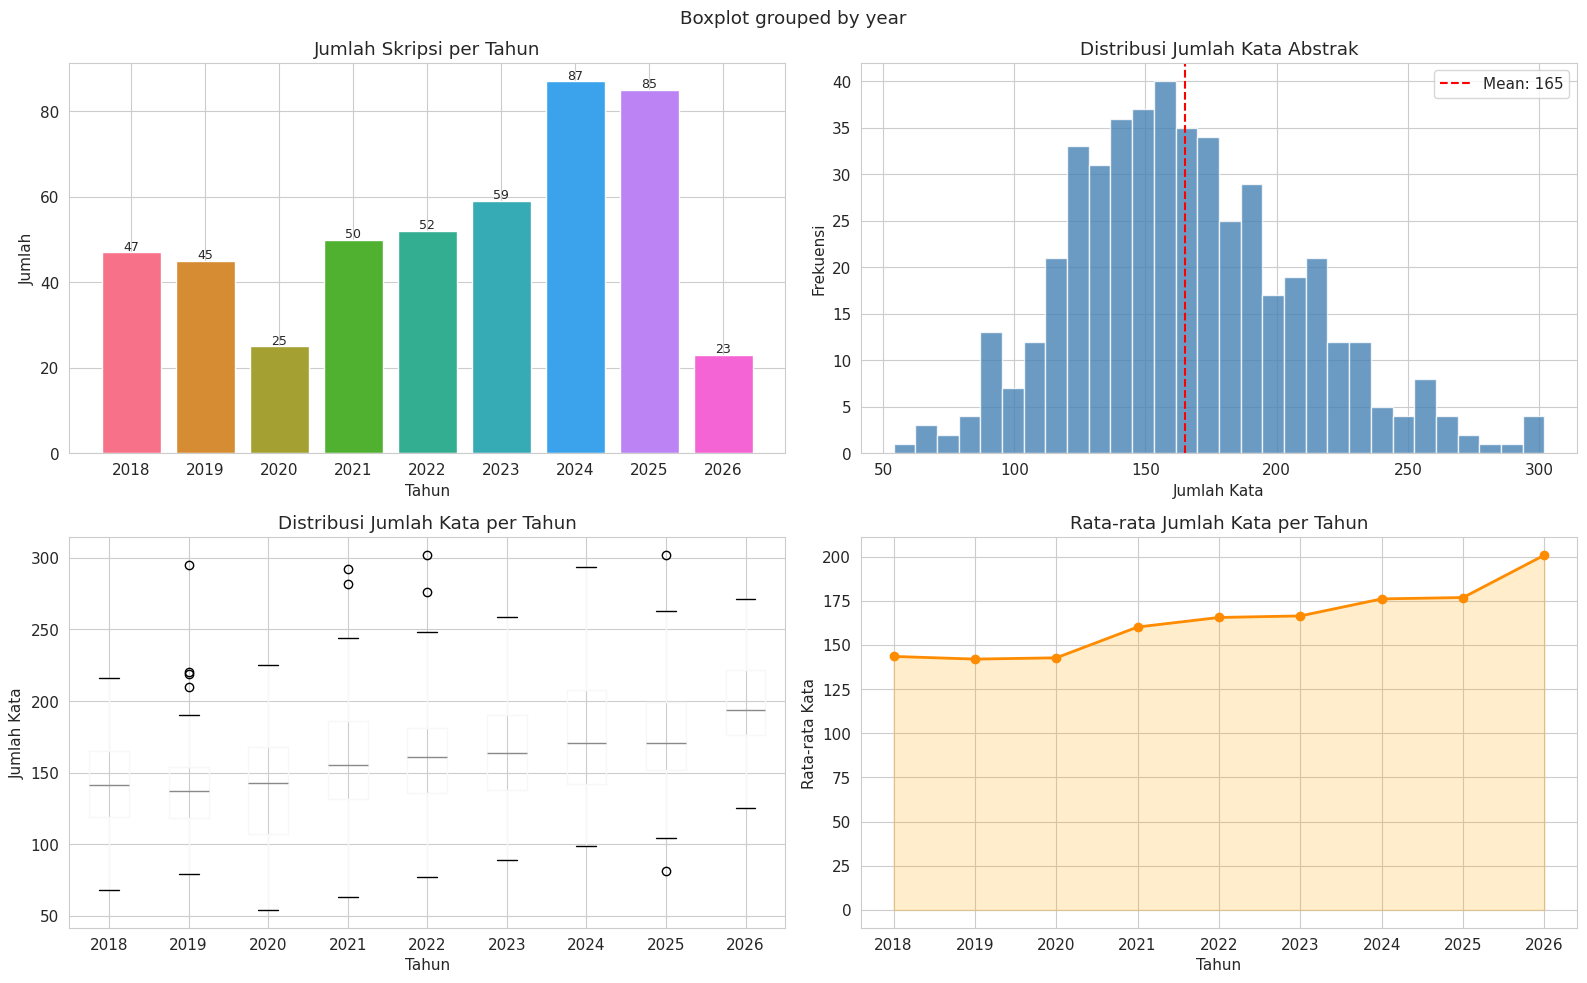

💾 Plot disimpan ke: step2_eda_overview.png


In [41]:
# ============================================
# 2.4 Visualisasi EDA
# ============================================

if DATA_READY:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Exploratory Data Analysis — Skripsi Informatika UNSOED", fontsize=14, fontweight="bold")
    
    # 1. Bar chart: Jumlah skripsi per tahun
    ax1 = axes[0, 0]
    year_counts = df_raw["year"].value_counts().sort_index()
    bars = ax1.bar(year_counts.index.astype(str), year_counts.values, color=sns.color_palette("husl", len(year_counts)))
    ax1.set_title("Jumlah Skripsi per Tahun")
    ax1.set_xlabel("Tahun")
    ax1.set_ylabel("Jumlah")
    for bar, val in zip(bars, year_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontsize=9)
    
    # 2. Histogram: Distribusi jumlah kata
    ax2 = axes[0, 1]
    ax2.hist(df_raw["word_count"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax2.axvline(df_raw["word_count"].mean(), color="red", linestyle="--", label=f"Mean: {df_raw['word_count'].mean():.0f}")
    ax2.set_title("Distribusi Jumlah Kata Abstrak")
    ax2.set_xlabel("Jumlah Kata")
    ax2.set_ylabel("Frekuensi")
    ax2.legend()
    
    # 3. Boxplot: Jumlah kata per tahun
    ax3 = axes[1, 0]
    df_raw.boxplot(column="word_count", by="year", ax=ax3)
    ax3.set_title("Distribusi Jumlah Kata per Tahun")
    ax3.set_xlabel("Tahun")
    ax3.set_ylabel("Jumlah Kata")
    plt.sca(ax3)
    plt.title("Distribusi Jumlah Kata per Tahun")
    
    # 4. Line chart: Tren rata-rata kata per tahun
    ax4 = axes[1, 1]
    avg_words = df_raw.groupby("year")["word_count"].mean()
    ax4.plot(avg_words.index, avg_words.values, marker='o', linewidth=2, color="darkorange")
    ax4.fill_between(avg_words.index, avg_words.values, alpha=0.2, color="orange")
    ax4.set_title("Rata-rata Jumlah Kata per Tahun")
    ax4.set_xlabel("Tahun")
    ax4.set_ylabel("Rata-rata Kata")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step2_eda_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step2_eda_overview.png")
else:
    print("⏭️ Langkah ini dilewati — data belum tersedia.")

---
## 3. 🔤 Text Preprocessing

### Catatan preprocessing
- `combined_text`: Judul + Abstrak (+ Kesimpulan jika valid).
- Dua pipeline:
  - **BERTopic**: deep-clean ringan + lowercase + normalisasi spasi (teks natural untuk embedding).
  - **LDA**: deep-clean + lowercase + hapus angka/simbol + stopword removal + stemming (Sastrawi).
- Fungsi `deep_clean_pdf_text` menghapus artefak umum hasil ekstraksi PDF/scraping (metadata EPrints, nomor halaman, header BAB/section, URL/email/DOI, dll).

In [42]:
from __future__ import annotations

from pathlib import Path

import nltk

def _find_project_nltk_data_dir() -> Path | None:
    start = Path.cwd().resolve()
    for path in [start, *start.parents]:
        candidate = path / "fastapi" / "nltk_data"
        if candidate.exists():
            return candidate
    return None

nltk_data_dir = _find_project_nltk_data_dir()
if nltk_data_dir:
    if str(nltk_data_dir) not in nltk.data.path:
        nltk.data.path.insert(0, str(nltk_data_dir))
    print(f"✅ Using project NLTK_DATA: {nltk_data_dir}")
else:
    print("⚠️ Project NLTK_DATA not found; using default NLTK paths.")

# Ensure stopwords corpus exists (download to a project-local dir if needed)
try:
    nltk.data.find("corpora/stopwords")
    print("✅ NLTK stopwords corpus tersedia.")
except LookupError:
    target_dir = nltk_data_dir or (Path.cwd() / "nltk_data")
    target_dir.mkdir(parents=True, exist_ok=True)
    if str(target_dir) not in nltk.data.path:
        nltk.data.path.insert(0, str(target_dir))
    ok = nltk.download("stopwords", download_dir=str(target_dir), quiet=True)
    if not ok:
        raise RuntimeError("Gagal mengunduh NLTK stopwords (cek koneksi internet atau permission folder).")
    nltk.data.find("corpora/stopwords")
    print(f"⬇️ Downloaded stopwords into: {target_dir}")

✅ Using project NLTK_DATA: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/nltk_data
✅ NLTK stopwords corpus tersedia.


In [43]:
import re

from nltk.corpus import stopwords as nltk_stopwords


def deep_clean_pdf_text(text: str) -> str:
    """Clean PDF extraction/scraping artifacts and normalize whitespace."""
    if not text or not isinstance(text, str):
        return ""

    text = text.replace("\\n", "\n")
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    text = re.sub(r"Item\s+Type\s*:.*", "", text, flags=re.DOTALL | re.IGNORECASE)

    metadata_patterns = [
        r"Nomor\s+Inventaris\s*:\s*\S+",
        r"Uncontrolled\s+Keywords\s*:.*?(?=\n[A-Z]|\Z)",
        r"Subjects\s*:[A-Z\s>]+[A-Z0-9\s]+",
        r"Divisions\s*:.*?(?=\n[A-Z]|\Z)",
        r"Depositing\s+User\s*:.*?(?=\n|\Z)",
        r"Date\s+Deposited\s*:.*?(?=\n|\Z)",
        r"Last\s+Modified\s*:.*?(?=\n|\Z)",
        r"URI\s*:\s*http\S*",
        r"[A-Z][a-z]+\s+[A-Z][a-z]+\s*:\s*[A-Z0-9\s]+(?=\n|$)",
    ]
    for pattern in metadata_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)

    text = re.sub(r"^\s*\d{1,4}\s*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"(?:^|\n)\s*\d{1,4}\s*(?:\n|$)", "\n", text)

    text = re.sub(r"\bBAB\s+[IVXLCDM]+\b", "", text, flags=re.IGNORECASE)

    section_headers = [
        r"KESIMPULAN\s+DAN\s+SARAN",
        r"KESIMPULAN\s*&\s*SARAN",
        r"PENUTUP",
        r"KESIMPULAN",
        r"SARAN",
        r"DAFTAR\s+PUSTAKA",
        r"DAFTAR\s+REFERENSI",
        r"ABSTRAK",
        r"ABSTRACT",
        r"KATA\s+PENGANTAR",
        r"DAFTAR\s+ISI",
        r"DAFTAR\s+GAMBAR",
        r"DAFTAR\s+TABEL",
        r"DAFTAR\s+LAMPIRAN",
        r"PENDAHULUAN",
        r"TINJAUAN\s+PUSTAKA",
        r"LANDASAN\s+TEORI",
        r"METODOLOGI\s+PENELITIAN",
        r"METODE\s+PENELITIAN",
        r"HASIL\s+DAN\s+PEMBAHASAN",
    ]
    for header in section_headers:
        text = re.sub(rf"(?:^|\n)\s*{header}\s*(?:\n|$)", "\n", text, flags=re.IGNORECASE)

    text = re.sub(r"(?:^|\n)\s*\d+\.\d+\.?\s*", "\n", text)
    text = re.sub(r"(?:^|\n)\s*\d+\.\s+", "\n", text)
    text = re.sub(r"(?:^|\n)\s*[a-z]\.\s+", "\n", text)

    text = re.sub(r"(?:Gambar|Tabel|Lampiran)\s+\d+[\.\-]?\s*\d*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"(?:halaman|hal\.?|hlm\.?)\s+\d+[\-–]?\d*", "", text, flags=re.IGNORECASE)

    text = re.sub(r"PDF\s*\([^)]*\)", "", text, flags=re.IGNORECASE)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"\S+@\S+\.\S+", "", text)
    text = re.sub(r"(?:doi|DOI)\s*:\s*\S+", "", text)
    text = re.sub(r"https?://doi\.org/\S+", "", text)

    text = text.replace("\u2013", "-").replace("\u2014", "-")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u2018", "'").replace("\u2019", "'")

    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_embedding(text: str) -> str:
    """Light cleaning for embedding (keep text natural)."""
    text = deep_clean_pdf_text(text)
    text = text.lower()
    text = re.sub(r"[^\x20-\x7E\u00C0-\u024F\u1E00-\u1EFF\w\s.,;:!?\"'()\-/]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_lda(text: str) -> str:
    """Stronger cleaning for LDA (BoW-based)."""
    text = deep_clean_pdf_text(text)
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if len(t) >= CONFIG["min_word_length"]]

    if CONFIG["remove_stopwords"]:
        tokens = [t for t in tokens if t not in stopword_set]

    if CONFIG["use_stemming"] and stemmer is not None:
        tokens = [stemmer.stem(t) for t in tokens]

    tokens = [t for t in tokens if len(t) >= CONFIG["min_word_length"]]
    return " ".join(tokens)


if DATA_READY:
    stopword_set = set(nltk_stopwords.words("indonesian"))
    academic_stopwords = {
        "penelitian", "menggunakan", "digunakan", "berdasarkan",
        "hasil", "menunjukkan", "bahwa", "dapat", "dilakukan",
        "metode", "sistem", "data", "proses", "dalam",
        "dengan", "untuk", "pada", "dari", "yang",
        "ini", "tersebut", "adalah", "merupakan", "yaitu",
        "juga", "serta", "atau", "dan", "di",
        "ke", "se", "ber", "ter", "per",
        "skripsi", "tugas", "akhir", "universitas", "mahasiswa",
        "informatika", "jurusan", "program", "studi",
        "satu", "dua", "tiga", "empat", "lima",
        "oleh", "akan", "telah", "tidak", "lebih",
        "secara", "melalui", "antara", "setiap", "hingga",
        "sebagai", "seperti", "agar", "bagi", "tentang",
    }
    stopword_set.update(academic_stopwords)
    stopword_list = list(stopword_set)

    print(f"✅ Stopwords loaded: {len(stopword_set)} kata")

    stemmer = None
    try:
        from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

        factory = StemmerFactory()
        if hasattr(factory, "createStemmer"):
            stemmer = factory.createStemmer()
        elif hasattr(factory, "create_stemmer"):
            stemmer = factory.create_stemmer()
        else:
            methods = [m for m in dir(factory) if "stem" in m.lower()]
            if methods:
                stemmer = getattr(factory, methods[0])()

        if stemmer is not None:
            test = stemmer.stem("berlari")
            print(f"✅ Sastrawi stemmer loaded (test: 'berlari' → '{test}')")
        else:
            print("⚠️ Sastrawi: tidak dapat membuat stemmer instance")
    except Exception as e:
        print(f"⚠️ Sastrawi error: {e}")

    print("\n⏳ Membuat kolom combined_text...")
    df_processed = df_raw.copy()

    def _is_valid_conclusion(text: str, min_chars: int = 100) -> bool:
        t = (text or "").strip()
        if not t:
            return False
        if t.lower() in ("nan", "none", "tidak tersedia"):
            return False
        return len(deep_clean_pdf_text(t)) >= min_chars

    def combine_text(row: pd.Series) -> str:
        title = deep_clean_pdf_text(str(row.get("title", "")).strip())
        abstract = deep_clean_pdf_text(str(row.get("abstract", "")).strip())
        conclusion = deep_clean_pdf_text(str(row.get("conclusion", "")).strip())

        if _is_valid_conclusion(conclusion, min_chars=100):
            return f"{title}. {abstract}. {conclusion}"
        return f"{title}. {abstract}"

    df_processed["combined_text"] = df_processed.apply(combine_text, axis=1)

    has_conclusion = df_processed["conclusion"].fillna("").astype(str).apply(
        lambda x: _is_valid_conclusion(x, min_chars=100)
    )
    n_with_conclusion = int(has_conclusion.sum())
    n_without_conclusion = int((~has_conclusion).sum())

    print("\n📊 Statistik combined_text:")
    print(f"   Dengan Kesimpulan : {n_with_conclusion} dokumen")
    print(f"   Tanpa Kesimpulan  : {n_without_conclusion} dokumen")
    print(f"   Total             : {len(df_processed)} dokumen")

    print("\n⏳ Menjalankan preprocessing...")
    start_time = time.time()

    df_processed["cleaned_text"] = df_processed["combined_text"].apply(clean_text_for_embedding)
    df_processed["processed_text"] = df_processed["combined_text"].apply(clean_text_for_lda)

    before_count = len(df_processed)
    mask = (
        (df_processed["cleaned_text"].str.strip().str.len() > 0)
        & (df_processed["processed_text"].str.strip().str.len() > 0)
    )
    df_processed = df_processed[mask].reset_index(drop=True)
    after_count = len(df_processed)

    if before_count != after_count:
        print(f"\n⚠️ {before_count - after_count} dokumen dihapus (teks kosong setelah cleaning)")

    duration = time.time() - start_time
    print(f"\n✅ Preprocessing selesai dalam {duration:.1f} detik")
    print(f"   Dokumen final: {len(df_processed)}")

    df_processed["cleaned_word_count"] = df_processed["cleaned_text"].str.split().str.len()
    df_processed["processed_word_count"] = df_processed["processed_text"].str.split().str.len()
else:
    print("⏭️ Langkah ini dilewati — data belum tersedia.")


✅ Stopwords loaded: 774 kata
✅ Sastrawi stemmer loaded (test: 'berlari' → 'lari')

⏳ Membuat kolom combined_text...

📊 Statistik combined_text:
   Dengan Kesimpulan : 325 dokumen
   Tanpa Kesimpulan  : 148 dokumen
   Total             : 473 dokumen

⏳ Menjalankan preprocessing...

✅ Preprocessing selesai dalam 364.1 detik
   Dokumen final: 473


In [44]:

# ============================================
# 3.2 Statistik Preprocessing & Tabel Before/After
# ============================================

if DATA_READY:
    # -- Tabel 1: Ringkasan Statistik Pipeline --
    prep_stats = {
        "Pipeline": ["Original (Abstrak)", "Cleaned (BERTopic)", "Processed (LDA)"],
        "Jumlah Dokumen": [
            len(df_raw),
            len(df_processed),
            len(df_processed),
        ],
        "Rata-rata Kata": [
            f"{df_raw['word_count'].mean():.1f}",
            f"{df_processed['cleaned_word_count'].mean():.1f}",
            f"{df_processed['processed_word_count'].mean():.1f}",
        ],
        "Min Kata": [
            int(df_raw["word_count"].min()),
            int(df_processed["cleaned_word_count"].min()),
            int(df_processed["processed_word_count"].min()),
        ],
        "Max Kata": [
            int(df_raw["word_count"].max()),
            int(df_processed["cleaned_word_count"].max()),
            int(df_processed["processed_word_count"].max()),
        ],
        "Keterangan": [
            "Teks abstrak asli dari JSON",
            "Deep clean PDF + case folding (teks natural untuk IndoSBERT)",
            "Deep clean PDF + hapus angka/simbol + stopword removal + stemming (untuk LDA)",
        ],
    }
    df_prep_stats = pd.DataFrame(prep_stats)
    df_prep_stats.to_csv(OUTPUT_CSV_DIR / "step3_preprocessing_statistics.csv", index=False)
    print("STATISTIK PREPROCESSING")
    print("="*60)
    print("Disimpan ke: step3_preprocessing_statistics.csv\n")
    display(df_prep_stats)

    # -- Tabel 2: Before vs After (per dokumen, 3 sampel) --
    print("\n" + "="*60)
    print("CONTOH BEFORE -> AFTER PREPROCESSING (3 Sampel)")
    print("="*60)

    n_samples = min(3, len(df_processed))
    before_after_records = []
    for i in range(n_samples):
        row = df_processed.iloc[i]
        mask_title = df_raw["title"] == row["title"]
        if mask_title.any():
            original_abstract = str(df_raw.loc[mask_title, "abstract"].values[0])
            kata_before = df_raw.loc[mask_title, "word_count"].values[0]
        else:
            original_abstract = str(row.get("abstract", ""))
            kata_before = "-"
        before_after_records.append({
            "No": i + 1,
            "Judul (singkat)": row["title"][:60] + "...",
            "BEFORE - Abstrak Asli (200 char)": original_abstract[:200].replace("\n", " ") + "...",
            "AFTER - Cleaned / BERTopic (200 char)": row["cleaned_text"][:200] + "...",
            "AFTER - Processed / LDA (200 char)": row["processed_text"][:200] + "...",
            "Kata (Before)": kata_before,
            "Kata (Cleaned)": row["cleaned_word_count"],
            "Kata (Processed)": row["processed_word_count"],
        })

    df_before_after = pd.DataFrame(before_after_records)

    pd.set_option("display.max_colwidth", 220)
    for _, sample in df_before_after.iterrows():
        print(f"\n-- Dokumen #{sample['No']}: {sample['Judul (singkat)']}")
        print(f"   [BEFORE] abstrak asli  [{sample['Kata (Before)']} kata]:")
        print(f"      {sample['BEFORE - Abstrak Asli (200 char)']}")
        print(f"   [AFTER]  cleaned (BERTopic) [{sample['Kata (Cleaned)']} kata]:")
        print(f"      {sample['AFTER - Cleaned / BERTopic (200 char)']}")
        print(f"   [AFTER]  processed (LDA)    [{sample['Kata (Processed)']} kata]:")
        print(f"      {sample['AFTER - Processed / LDA (200 char)']}")
    pd.reset_option("display.max_colwidth")

    # -- Simpan CSV step3 -- hanya kolom yang diperlukan --
    save_cols = [
        "title", "author", "year", "keywords", "divisions",
        "combined_text", "cleaned_text", "processed_text",
        "cleaned_word_count", "processed_word_count",
        "conclusion_source",
    ]
    save_cols_existing = [c for c in save_cols if c in df_processed.columns]
    df_processed[save_cols_existing].to_csv(
        OUTPUT_CSV_DIR / "step3_processed_data.csv", index=False
    )
    print(f"\nData processed disimpan ke: step3_processed_data.csv")
    print(f"Kolom: {save_cols_existing}")
    print(f"Dokumen: {len(df_processed)}")
else:
    print("Langkah ini dilewati.")


STATISTIK PREPROCESSING
Disimpan ke: step3_preprocessing_statistics.csv



,Pipeline,Jumlah Dokumen,Rata-rata Kata,Min Kata,Max Kata,Keterangan
0,Original (Abstrak),473,165.1,54,302,Teks abstrak asli dari JSON
1,Cleaned (BERTopic),473,284.9,71,950,Deep clean PDF + case folding (teks natural un...
2,Processed (LDA),473,156.9,39,605,Deep clean PDF + hapus angka/simbol + stopword...



CONTOH BEFORE -> AFTER PREPROCESSING (3 Sampel)

-- Dokumen #1: Perbandingan Metode Grid Search, Random Search, dan Bayesian...
   [BEFORE] abstrak asli  [177 kata]:
      Layanan perpajakan digital Website Coretax yang baru disahkan pada awal tahun 2025 memicu beragam opini masyarakat di platform media sosial X. Analisis sentimen terhadap opini tersebut penting dilakuk...
   [AFTER]  cleaned (BERTopic) [429 kata]:
      perbandingan metode grid search, random search, dan bayesian optimization dalam optimasi hyperparameter model bert untuk analisis sentimen pada platform x terhadap website coretax. layanan perpajakan ...
   [AFTER]  processed (LDA)    [228 kata]:
      banding grid search random search bayesian optimization optimasi hyperparameter model bert analisis sentimen platform website coretax layan paja digital website coretax sah picu agam opini masyarakat ...

-- Dokumen #2: Klasterisasi Produktivitas Pertanian di Kabupaten Batang Ber...
   [BEFORE] abstrak asli  [194 kata]:

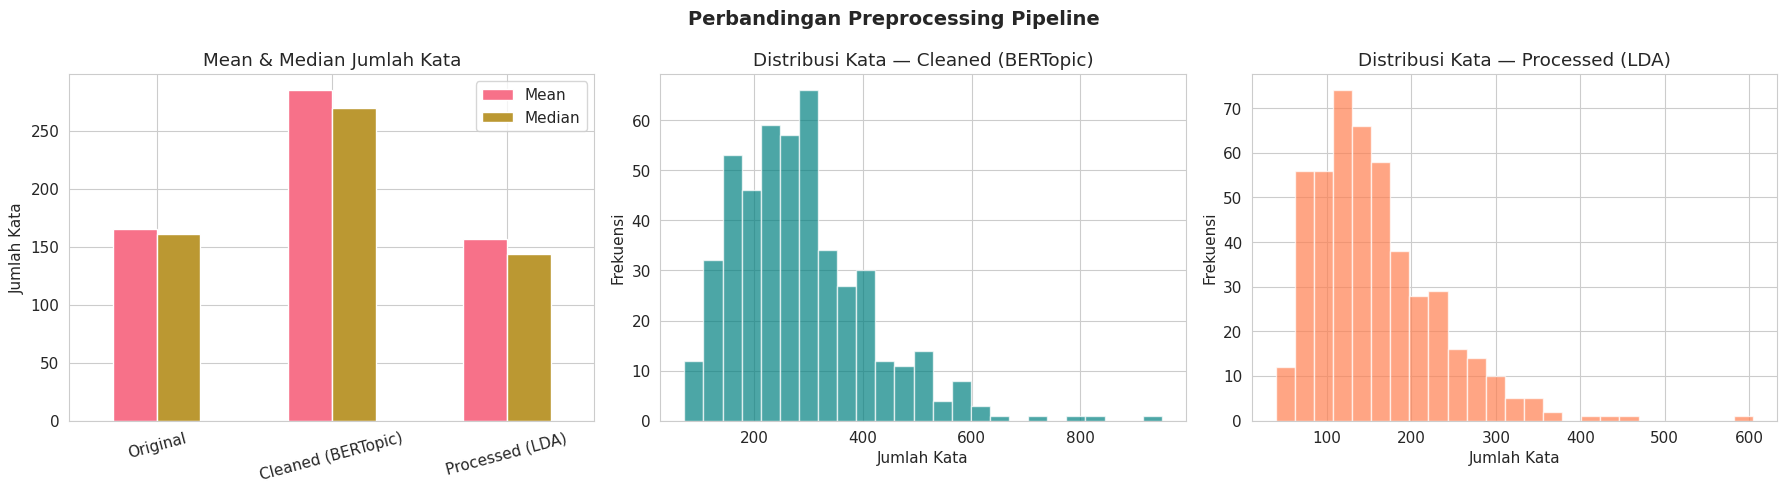

💾 Plot disimpan ke: step3_preprocessing_comparison.png


In [45]:
# ============================================
# 3.3 Visualisasi Preprocessing
# ============================================

if DATA_READY:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Perbandingan Preprocessing Pipeline", fontsize=14, fontweight="bold")
    
    # 1. Perbandingan jumlah kata
    ax1 = axes[0]
    comparison_data = pd.DataFrame({
        "Original": df_raw["word_count"].describe(),
        "Cleaned (BERTopic)": df_processed["cleaned_word_count"].describe(),
        "Processed (LDA)": df_processed["processed_word_count"].describe(),
    }).T
    comparison_data[["mean", "50%"]].plot(kind="bar", ax=ax1)
    ax1.set_title("Mean & Median Jumlah Kata")
    ax1.set_ylabel("Jumlah Kata")
    ax1.tick_params(axis='x', rotation=15)
    ax1.legend(["Mean", "Median"])
    
    # 2. Distribusi cleaned
    ax2 = axes[1]
    ax2.hist(df_processed["cleaned_word_count"], bins=25, alpha=0.7, color="teal", edgecolor="white")
    ax2.set_title("Distribusi Kata — Cleaned (BERTopic)")
    ax2.set_xlabel("Jumlah Kata")
    ax2.set_ylabel("Frekuensi")
    
    # 3. Distribusi processed (stemmed)
    ax3 = axes[2]
    ax3.hist(df_processed["processed_word_count"], bins=25, alpha=0.7, color="coral", edgecolor="white")
    ax3.set_title("Distribusi Kata — Processed (LDA)")
    ax3.set_xlabel("Jumlah Kata")
    ax3.set_ylabel("Frekuensi")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step3_preprocessing_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step3_preprocessing_comparison.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 4. 🧠 BERTopic — Compute Embeddings

In [46]:
# ============================================
# 4.1 Compute / Load Sentence Embeddings (IndoSBERT-large)
# ============================================
# Embeddings dihitung SEKALI dan di-reuse untuk semua kombinasi hyperparameter.

if DATA_READY:
    from sentence_transformers import SentenceTransformer
    
    embedding_model_name = CONFIG["embedding_model"]
    embeddings_path = OUTPUT_MODEL_DIR / "embeddings_indosbert_large.npy"
    
    documents_cleaned = df_processed["cleaned_text"].tolist()
    documents_stemmed = df_processed["processed_text"].tolist()
    
    # Load model (dibutuhkan untuk BERTopic training, walau embeddings di-load dari file)
    print(f"⏳ Loading model: {embedding_model_name}")
    print("   Output dim : 256 (setelah Dense layer pada denaya/indoSBERT-large)")
    cache_dir = OUTPUT_MODEL_DIR / "hf_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    st_model = SentenceTransformer(embedding_model_name, cache_folder=str(cache_dir))
    
    # Load embeddings jika sudah ada dan ukurannya cocok
    if embeddings_path.exists():
        try:
            embeddings = np.load(embeddings_path)
            if embeddings.shape[0] == len(documents_cleaned):
                print(f"✅ Embeddings di-load dari file: {embeddings_path}")
                print(f"   Shape: {embeddings.shape}")
            else:
                print("⚠️ Embeddings file ada, tapi jumlah dokumen tidak cocok. Akan dihitung ulang.")
                embeddings = None
        except Exception as e:
            print(f"⚠️ Gagal load embeddings ({e}). Akan dihitung ulang.")
            embeddings = None
    else:
        embeddings = None
    
    if embeddings is None:
        print(f"\n⏳ Computing embeddings untuk {len(documents_cleaned)} dokumen...")
        start_time = time.time()
        embeddings = st_model.encode(
            documents_cleaned,
            show_progress_bar=True,
            batch_size=CONFIG["embedding_batch_size"],
        )
        embed_duration = time.time() - start_time
        print(f"\n✅ Embeddings selesai dalam {embed_duration:.1f} detik")
        print(f"   Shape: {embeddings.shape}  (dokumen × dimensi)")
        
        np.save(embeddings_path, embeddings)
        print(f"💾 Embeddings disimpan ke: {embeddings_path.name}")
    
    # Validasi dimensi
    assert embeddings.ndim == 2 and embeddings.shape[1] == 256, f"⚠️ Dimensi tidak sesuai: {embeddings.shape} (expected (n, 256))"
    
    # Simpan info
    embed_info = pd.DataFrame([{
        "model": embedding_model_name,
        "num_documents": int(embeddings.shape[0]),
        "embedding_dim": int(embeddings.shape[1]),
        "batch_size": int(CONFIG["embedding_batch_size"]),
        "embeddings_file": str(embeddings_path),
    }])
    embed_info.to_csv(OUTPUT_CSV_DIR / "step4_embedding_info.csv", index=False)
    display(embed_info)
else:
    print("⏭️ Langkah ini dilewati.")

⏳ Loading model: denaya/indoSBERT-large
   Output dim : 256 (setelah Dense layer pada denaya/indoSBERT-large)
✅ Embeddings di-load dari file: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/models/embeddings_indosbert_large.npy
   Shape: (473, 256)


,model,num_documents,embedding_dim,batch_size,embeddings_file
0,denaya/indoSBERT-large,473,256,16,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...


---
## 5. 🔬 Hyperparameter Tuning — BERTopic

In [47]:
# ============================================
# 5.1 BERTopic Grid Search
# ============================================

from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from gensim.corpora import Dictionary

if DATA_READY:
    coherence_type = str(CONFIG.get("coherence_type", "c_v"))
    coherence_dict_no_below = int(CONFIG.get("coherence_dict_no_below", 3))
    coherence_dict_no_above = float(CONFIG.get("coherence_dict_no_above", 0.95))
    coherence_tokenization = str(CONFIG.get("coherence_tokenization", "vectorizer")).strip().lower()
    if coherence_tokenization != "vectorizer":
        print(f"⚠️ coherence_tokenization={coherence_tokenization} diabaikan. Dipaksa ke 'vectorizer' agar konsisten.")
        coherence_tokenization = "vectorizer"

    all_params = list(iter_grid_params(CONFIG["bertopic_grid"]))
    seed = int(CONFIG.get("bertopic_random_state_grid", RANDOM_STATE))
    max_runs = int(CONFIG.get("bertopic_n_sample", CONFIG.get("grid_max_samples", len(all_params))))

    if max_runs <= 0 or max_runs >= len(all_params):
        sampled_params = all_params
    else:
        sampled_params = sample_params(all_params, n=max_runs, seed=seed)

    reduce_outliers_enabled = bool(CONFIG.get("tuning_reduce_outliers", False))
    th_ctfidf = float(CONFIG.get("tuning_reduce_outliers_threshold_ctfidf", 0.1))
    use_distributions = bool(CONFIG.get("tuning_reduce_outliers_use_distributions", True))
    th_dist = float(CONFIG.get("tuning_reduce_outliers_threshold_distributions", 0.05))

    use_mmr = bool(CONFIG.get("tuning_use_mmr_representation", False))
    mmr_diversity = float(CONFIG.get("tuning_mmr_diversity", 0.3))
    mmr_model = None
    if use_mmr:
        from bertopic.representation import MaximalMarginalRelevance

        mmr_model = MaximalMarginalRelevance(diversity=mmr_diversity)

    print("\n🔬 BERTopic Grid Search")
    print(f"   Total kombinasi     : {len(all_params)}")
    print(f"   Kombinasi dieksekusi: {len(sampled_params)}")
    print(f"   Embedding shape     : {embeddings.shape}")
    print(f"   coherence tokenization: {coherence_tokenization}")
    print(f"   reduce_outliers tuning: {reduce_outliers_enabled}")
    if reduce_outliers_enabled:
        print(f"   thresholds            : ctfidf={th_ctfidf}, distributions={th_dist} (enabled={use_distributions})")
    print(f"   representation (MMR)  : {use_mmr} (diversity={mmr_diversity if use_mmr else 'N/A'})")
    print("=" * 70)

    bt_results = []
    csv_path_bt = OUTPUT_CSV_DIR / "step5_bertopic_tuning_results.csv"

    for idx, params in enumerate(sampled_params):
        run_id = f"BT_{idx+1:03d}"

        vec_ngram = params.get("vectorizer_ngram_range")
        vec_min_df = params.get("vectorizer_min_df")
        vec_max_df = params.get("vectorizer_max_df")
        nr_topics_raw = params.get("nr_topics")

        print(
            f"\n[{idx+1}/{len(sampled_params)}] {run_id}: "
            f"nn={params['umap_n_neighbors']} nc={params['umap_n_components']} md={params['umap_min_dist']} "
            f"mcs={params['hdbscan_min_cluster_size']} ms={params['hdbscan_min_samples']} "
            f"mts={params['min_topic_size']} nr={nr_topics_raw} "
            f"vec(ngram={vec_ngram}, min_df={vec_min_df}, max_df={vec_max_df})"
        )

        start = time.time()
        vectorizer_fallback = False

        try:
            umap_model = UMAP(
                n_neighbors=int(params["umap_n_neighbors"]),
                n_components=int(params["umap_n_components"]),
                min_dist=float(params["umap_min_dist"]),
                metric=str(params["umap_metric"]),
                random_state=RANDOM_STATE,
            )

            hdbscan_model = HDBSCAN(
                min_cluster_size=int(params["hdbscan_min_cluster_size"]),
                min_samples=int(params["hdbscan_min_samples"]),
                metric=str(params["hdbscan_metric"]),
                cluster_selection_method=str(params["hdbscan_method"]),
                prediction_data=True,
            )

            if nr_topics_raw is None:
                nr_topics_val = None
            elif isinstance(nr_topics_raw, str):
                nr_topics_val = nr_topics_raw
            else:
                nr_topics_val = int(nr_topics_raw)

            vectorizer = build_vectorizer(
                stopword_list,
                min_df=vec_min_df,
                max_df=vec_max_df,
                ngram_range=vec_ngram,
            )

            def _fit_with_vectorizer(v):
                model = BERTopic(
                    embedding_model=st_model,
                    umap_model=umap_model,
                    hdbscan_model=hdbscan_model,
                    vectorizer_model=v,
                    representation_model=mmr_model,
                    top_n_words=int(CONFIG["top_n_words"]),
                    min_topic_size=int(params["min_topic_size"]),
                    nr_topics=nr_topics_val,
                    verbose=False,
                )
                topics, _ = model.fit_transform(documents_cleaned, embeddings=embeddings)
                return model, topics

            try:
                bt_model, topics = _fit_with_vectorizer(vectorizer)
            except ValueError as e:
                if is_vectorizer_df_error(e):
                    vectorizer_fallback = True
                    vectorizer = build_vectorizer(
                        stopword_list,
                        min_df=CONFIG.get("vectorizer_fallback_min_df", 1),
                        max_df=CONFIG.get("vectorizer_fallback_max_df", 1.0),
                        ngram_range=vec_ngram,
                    )
                    bt_model, topics = _fit_with_vectorizer(vectorizer)
                else:
                    raise

            topic_info = bt_model.get_topic_info()
            num_topics_before = int(len(topic_info) - 1)
            n_outliers_before = int((np.array(topics) == -1).sum())
            outlier_pct_before = round(n_outliers_before / len(documents_cleaned) * 100, 2)

            topics_for_eval = topics
            num_topics_after = num_topics_before
            n_outliers_after = n_outliers_before
            outlier_pct_after = outlier_pct_before

            if reduce_outliers_enabled:
                try:
                    topics_reduced = bt_model.reduce_outliers(
                        documents_cleaned,
                        topics_for_eval,
                        strategy="c-tf-idf",
                        threshold=th_ctfidf,
                    )

                    if use_distributions and int((np.array(topics_reduced) == -1).sum()) > 0:
                        topics_reduced = bt_model.reduce_outliers(
                            documents_cleaned,
                            topics_reduced,
                            strategy="distributions",
                            threshold=th_dist,
                        )

                    update_kwargs = {"vectorizer_model": vectorizer}
                    if mmr_model is not None:
                        update_kwargs["representation_model"] = mmr_model

                    bt_model.update_topics(
                        documents_cleaned,
                        topics=topics_reduced,
                        **update_kwargs,
                    )
                    topics_for_eval = topics_reduced
                except Exception as e:
                    print(f"   ⚠️ reduce_outliers gagal, lanjut tanpa reduce_outliers: {str(e)[:120]}")
                    topics_for_eval = topics

                topic_info = bt_model.get_topic_info()
                num_topics_after = int(len(topic_info) - 1)
                n_outliers_after = int((np.array(topics_for_eval) == -1).sum())
                outlier_pct_after = round(n_outliers_after / len(documents_cleaned) * 100, 2)

            num_topics = num_topics_after
            outlier_pct = outlier_pct_after

            bt_topic_words = bertopic_topic_words(bt_model, top_n_words=int(CONFIG["top_n_words"]))
            analyzer = vectorizer.build_analyzer()
            tokenized_for_cv = [analyzer(doc) for doc in documents_cleaned]
            dictionary_for_cv = Dictionary(tokenized_for_cv)
            dictionary_for_cv.filter_extremes(
                no_below=coherence_dict_no_below,
                no_above=coherence_dict_no_above,
            )

            coherence_cv = coherence_score_cv(
                bt_topic_words,
                tokenized_texts=tokenized_for_cv,
                dictionary=dictionary_for_cv,
                coherence=coherence_type,
            )
            diversity = topic_diversity(bt_topic_words, top_n_words=int(CONFIG["top_n_words"]))

            coh_for_score = 0.0 if pd.isna(coherence_cv) else float(coherence_cv)
            div_for_score = 0.0 if pd.isna(diversity) else float(diversity)
            score_composite = round(coh_for_score * div_for_score * (1 - outlier_pct / 100.0), 6)

            duration = round(time.time() - start, 2)

            result_row = {
                "run_id": run_id,
                **params,
                "nr_topics": nr_topics_raw,
                "vectorizer_min_df": vectorizer.min_df,
                "vectorizer_max_df": vectorizer.max_df,
                "vectorizer_fallback": vectorizer_fallback,
                "num_topics": num_topics,
                "num_topics_before": num_topics_before,
                "num_topics_after": num_topics_after,
                "coherence_cv": coherence_cv,
                "topic_diversity": diversity,
                "outlier_pct": outlier_pct,
                "outlier_pct_before": outlier_pct_before,
                "outlier_pct_after": outlier_pct_after,
                "score_composite": score_composite,
                "duration_sec": duration,
                "status": "success",
            }

            note = " (fallback vec)" if vectorizer_fallback else ""
            if reduce_outliers_enabled:
                print(
                    f"   OK{note} topics={num_topics} cv={coherence_cv} div={diversity} "
                    f"outlier={outlier_pct}% (before={outlier_pct_before}%) score={score_composite} t={duration}s"
                )
            else:
                print(
                    f"   OK{note} topics={num_topics} cv={coherence_cv} div={diversity} "
                    f"outlier={outlier_pct}% score={score_composite} t={duration}s"
                )
        except Exception as e:
            duration = round(time.time() - start, 2)
            result_row = {
                "run_id": run_id,
                **params,
                "nr_topics": nr_topics_raw,
                "vectorizer_min_df": float("nan"),
                "vectorizer_max_df": float("nan"),
                "vectorizer_fallback": vectorizer_fallback,
                "num_topics": 0,
                "num_topics_before": float("nan"),
                "num_topics_after": float("nan"),
                "coherence_cv": float("nan"),
                "topic_diversity": float("nan"),
                "outlier_pct": float("nan"),
                "outlier_pct_before": float("nan"),
                "outlier_pct_after": float("nan"),
                "score_composite": float("nan"),
                "duration_sec": duration,
                "status": f"error: {str(e)[:120]}",
            }
            print(f"   ERR {str(e)[:100]}")

        bt_results.append(result_row)
        pd.DataFrame(bt_results).to_csv(csv_path_bt, index=False)

    df_bt_results = pd.DataFrame(bt_results)
    n_success = int((df_bt_results["status"] == "success").sum())
    n_error = int((df_bt_results["status"] != "success").sum())

    print(f"\n{'='*70}")
    print("BERTopic Grid Search selesai!")
    print(f"   Eksperimen berhasil : {n_success}")
    print(f"   Eksperimen error    : {n_error}")
    print("   Disimpan ke         : step5_bertopic_tuning_results.csv")
else:
    print("⏭️ Langkah ini dilewati.")


🔬 BERTopic Grid Search
   Total kombinasi     : 24
   Kombinasi dieksekusi: 24
   Embedding shape     : (473, 256)
   coherence tokenization: vectorizer
   reduce_outliers tuning: True
   thresholds            : ctfidf=0.1, distributions=0.05 (enabled=True)
   representation (MMR)  : True (diversity=0.3)

[1/24] BT_001: nn=25 nc=5 md=0.0 mcs=8 ms=1 mts=12 nr=auto vec(ngram=(1, 2), min_df=2, max_df=0.9)


2026-04-05 01:19:51,158 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


   OK topics=7 cv=0.3966 div=0.8875 outlier=0.0% (before=18.82%) score=0.351982 t=63.13s

[2/24] BT_002: nn=25 nc=5 md=0.0 mcs=8 ms=1 mts=12 nr=auto vec(ngram=(1, 2), min_df=2, max_df=0.95)


2026-04-05 01:20:46,674 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


   OK topics=7 cv=0.3966 div=0.8875 outlier=0.0% (before=18.82%) score=0.351982 t=55.96s

[3/24] BT_003: nn=25 nc=5 md=0.0 mcs=12 ms=1 mts=12 nr=auto vec(ngram=(1, 2), min_df=2, max_df=0.9)


...

   OK topics=10 cv=0.4516 div=0.8818 outlier=0.0% (before=24.31%) score=0.398221 t=67.56s

[23/24] BT_023: nn=55 nc=5 md=0.1 mcs=12 ms=1 mts=12 nr=auto vec(ngram=(1, 2), min_df=2, max_df=0.9)


2026-04-05 01:42:04,061 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


   OK topics=7 cv=0.4723 div=0.9 outlier=0.0% (before=30.87%) score=0.42507 t=49.36s

[24/24] BT_024: nn=55 nc=5 md=0.1 mcs=12 ms=1 mts=12 nr=auto vec(ngram=(1, 2), min_df=2, max_df=0.95)


2026-04-05 01:42:54,064 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


   OK topics=7 cv=0.4723 div=0.9 outlier=0.0% (before=30.87%) score=0.42507 t=61.49s

BERTopic Grid Search selesai!
   Eksperimen berhasil : 24
   Eksperimen error    : 0
   Disimpan ke         : step5_bertopic_tuning_results.csv


In [48]:
# ============================================
# 5.2 BERTopic Tuning Results — Tabel
# ============================================

if DATA_READY:
    df_bt_success = df_bt_results[df_bt_results["status"] == "success"].copy()

    sort_col = "score_composite" if "score_composite" in df_bt_success.columns else "coherence_cv"
    df_bt_sorted = df_bt_success.sort_values(sort_col, ascending=False).reset_index(drop=True)

    print("📊 Distribusi Jumlah Topik dari semua eksperimen berhasil:")
    topic_dist = df_bt_success["num_topics"].value_counts().sort_index()
    for n, cnt in topic_dist.items():
        bar = "█" * min(cnt, 30)
        print(f"   {n:3d} topik : {bar} ({cnt}x)")

    # ─── Sweet spot: 8–30 topik ───
    # Terlalu sedikit (<8) → tidak informatif untuk skripsi
    # Terlalu banyak (>30) → topik terlalu micro/fragmentasi
    MIN_T, MAX_T = 8, 30
    df_bt_filtered = df_bt_success[
        df_bt_success["num_topics"].between(MIN_T, MAX_T)
    ].sort_values(sort_col, ascending=False).reset_index(drop=True)

    if len(df_bt_filtered) == 0:
        print(f"\n⚠️  Tidak ada hasil di range {MIN_T}–{MAX_T} topik, gunakan semua.")
        df_bt_filtered = df_bt_sorted.copy()

    print(f"\n🏆 Top 10 Kombinasi BERTopic (range {MIN_T}–{MAX_T} topik, sort {sort_col}):")

    show_cols = [
        "run_id",
        "umap_n_neighbors",
        "umap_n_components",
        "umap_min_dist",
        "hdbscan_min_cluster_size",
        "hdbscan_min_samples",
        "hdbscan_method",
        "min_topic_size",
        "nr_topics",
        "vectorizer_ngram_range",
        "vectorizer_min_df",
        "vectorizer_max_df",
        "vectorizer_fallback",
        "num_topics",
        "num_topics_before",
        "num_topics_after",
        "coherence_cv",
        "topic_diversity",
        "outlier_pct",
        "outlier_pct_before",
        "outlier_pct_after",
        "score_composite",
        "duration_sec",
    ]
    show_cols_existing = [c for c in show_cols if c in df_bt_filtered.columns]

    display(df_bt_filtered.head(10)[show_cols_existing])

    best_bt = df_bt_filtered.iloc[0]
    print(f"\n🥇 Parameter Terbaik BERTopic: {best_bt['run_id']}")
    if sort_col in best_bt.index:
        print(f"   Skor ({sort_col})  : {best_bt[sort_col]}")
    print(f"   Coherence C_v      : {best_bt['coherence_cv']}")
    print(f"   Topic Diversity    : {best_bt['topic_diversity']}")
    print(f"   Jumlah Topik       : {best_bt['num_topics']}")
    print(f"   Outlier %          : {best_bt['outlier_pct']}%")

    if "outlier_pct_before" in best_bt.index and "outlier_pct_after" in best_bt.index:
        print(f"   Outlier % (before) : {best_bt['outlier_pct_before']}%")
        print(f"   Outlier % (after)  : {best_bt['outlier_pct_after']}%")

    print(f"   UMAP n_neighbors   : {best_bt['umap_n_neighbors']}")
    print(f"   UMAP n_components  : {best_bt['umap_n_components']}")
    print(f"   UMAP min_dist      : {best_bt['umap_min_dist']}")

    print(f"   HDBSCAN cluster sz : {best_bt['hdbscan_min_cluster_size']}")
    print(f"   HDBSCAN min_samples: {best_bt.get('hdbscan_min_samples', 'N/A')}")
    print(f"   HDBSCAN method     : {best_bt['hdbscan_method']}")

    print(f"   min_topic_size     : {best_bt['min_topic_size']}")
    if "nr_topics" in best_bt.index:
        print(f"   nr_topics          : {best_bt['nr_topics']}")

    if "vectorizer_min_df" in best_bt.index:
        print(
            "   Vectorizer         : "
            f"ngram={best_bt.get('vectorizer_ngram_range', 'N/A')}, "
            f"min_df={best_bt.get('vectorizer_min_df', 'N/A')}, "
            f"max_df={best_bt.get('vectorizer_max_df', 'N/A')}"
        )
else:
    print("⏭️ Langkah ini dilewati.")


📊 Distribusi Jumlah Topik dari semua eksperimen berhasil:
     6 topik : ██ (2x)
     7 topik : ████ (4x)
     9 topik : ██████ (6x)
    10 topik : ██████ (6x)
    11 topik : ████ (4x)
    21 topik : ██ (2x)

🏆 Top 10 Kombinasi BERTopic (range 8–30 topik, sort score_composite):


,run_id,umap_n_neighbors,umap_n_components,umap_min_dist,hdbscan_min_cluster_size,hdbscan_min_samples,hdbscan_method,min_topic_size,nr_topics,vectorizer_ngram_range,...,num_topics,num_topics_before,num_topics_after,coherence_cv,topic_diversity,outlier_pct,outlier_pct_before,outlier_pct_after,score_composite,duration_sec
0,BT_018,55,5,0.0,8,1,eom,12,auto,"(1, 2)",...,10,11,10,0.4616,0.9364,0.0,22.83,0.0,0.432242,65.35
1,BT_005,25,5,0.1,8,1,eom,12,auto,"(1, 2)",...,11,12,11,0.4564,0.9417,0.0,22.41,0.0,0.429792,67.49
2,BT_003,25,5,0.0,12,1,eom,12,auto,"(1, 2)",...,9,10,9,0.4420,0.9500,0.0,16.91,0.0,0.419900,52.68
3,BT_006,25,5,0.1,8,1,eom,12,auto,"(1, 2)",...,11,12,11,0.4278,0.9500,0.0,22.41,0.0,0.406410,65.30
4,BT_017,55,5,0.0,8,1,eom,12,auto,"(1, 2)",...,10,11,10,0.4396,0.9182,0.0,22.83,0.0,0.403641,65.64
5,BT_021,55,5,0.1,8,1,eom,12,auto,"(1, 2)",...,10,11,10,0.4253,0.9364,0.0,24.31,0.0,0.398251,67.96
6,BT_022,55,5,0.1,8,1,eom,12,auto,"(1, 2)",...,10,11,10,0.4516,0.8818,0.0,24.31,0.0,0.398221,67.56
7,BT_004,25,5,0.0,12,1,eom,12,auto,"(1, 2)",...,9,10,9,0.4222,0.9400,0.0,16.91,0.0,0.396868,51.34
8,BT_014,40,5,0.1,8,1,eom,12,auto,"(1, 2)",...,10,11,10,0.4294,0.9182,0.0,24.52,0.0,0.394275,65.61
9,BT_011,40,5,0.0,12,1,eom,12,auto,"(1, 2)",...,11,12,11,0.4248,0.9250,0.0,9.30,0.0,0.392940,59.70



🥇 Parameter Terbaik BERTopic: BT_018
   Skor (score_composite)  : 0.432242
   Coherence C_v      : 0.4616
   Topic Diversity    : 0.9364
   Jumlah Topik       : 10
   Outlier %          : 0.0%
   Outlier % (before) : 22.83%
   Outlier % (after)  : 0.0%
   UMAP n_neighbors   : 55
   UMAP n_components  : 5
   UMAP min_dist      : 0.0
   HDBSCAN cluster sz : 8
   HDBSCAN min_samples: 1
   HDBSCAN method     : eom
   min_topic_size     : 12
   nr_topics          : auto
   Vectorizer         : ngram=(1, 2), min_df=2, max_df=0.95


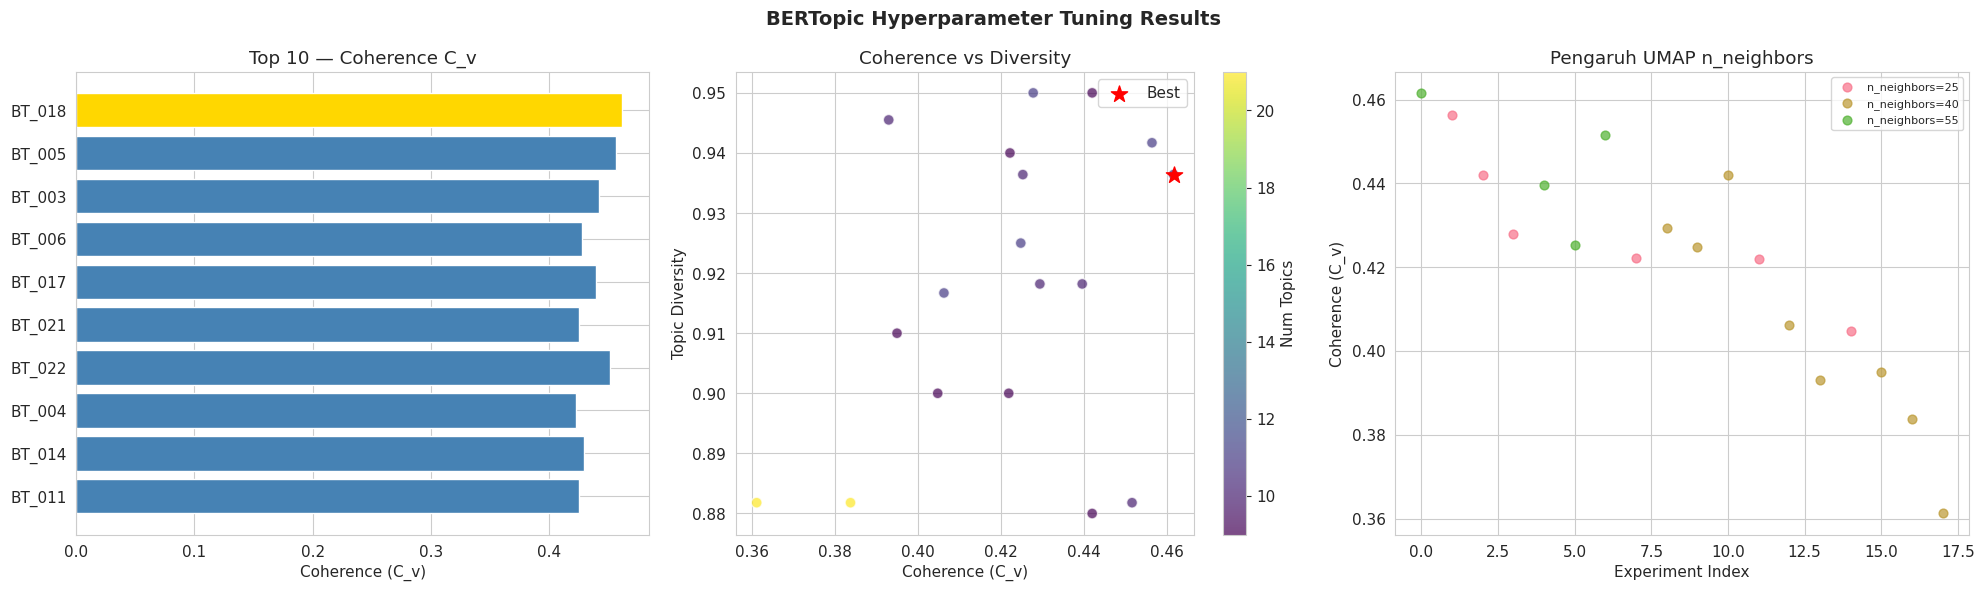

💾 Plot disimpan ke: step5_bertopic_tuning_results.png


In [49]:
# ============================================
# 5.3 Visualisasi BERTopic Tuning
# ============================================

if DATA_READY and len(df_bt_sorted) > 0:
    plot_df = df_bt_filtered if "df_bt_filtered" in globals() and len(df_bt_filtered) > 0 else df_bt_sorted

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("BERTopic Hyperparameter Tuning Results", fontsize=14, fontweight="bold")

    ax1 = axes[0]
    top10 = plot_df.head(10)
    colors = ["gold" if i == 0 else "steelblue" for i in range(len(top10))]
    ax1.barh(top10["run_id"][::-1], top10["coherence_cv"][::-1], color=colors[::-1])
    ax1.set_xlabel("Coherence (C_v)")
    ax1.set_title("Top 10 — Coherence C_v")

    ax2 = axes[1]
    sc = ax2.scatter(
        plot_df["coherence_cv"],
        plot_df["topic_diversity"],
        c=plot_df["num_topics"],
        cmap="viridis",
        s=60,
        alpha=0.7,
        edgecolors="white",
    )
    plt.colorbar(sc, ax=ax2, label="Num Topics")
    ax2.set_xlabel("Coherence (C_v)")
    ax2.set_ylabel("Topic Diversity")
    ax2.set_title("Coherence vs Diversity")

    if "best_bt" in globals():
        ax2.scatter(
            [best_bt["coherence_cv"]],
            [best_bt["topic_diversity"]],
            color="red",
            s=150,
            marker="*",
            zorder=5,
            label="Best",
        )
        ax2.legend()

    ax3 = axes[2]
    for nn in sorted(plot_df["umap_n_neighbors"].unique()):
        subset = plot_df[plot_df["umap_n_neighbors"] == nn]
        ax3.scatter(
            subset.index,
            subset["coherence_cv"],
            label=f"n_neighbors={nn}",
            s=40,
            alpha=0.7,
        )
    ax3.set_xlabel("Experiment Index")
    ax3.set_ylabel("Coherence (C_v)")
    ax3.set_title("Pengaruh UMAP n_neighbors")
    ax3.legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step5_bertopic_tuning_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step5_bertopic_tuning_results.png")
else:
    print("⏭️ Langkah ini dilewati.")


---
## 6. 🔬 Hyperparameter Tuning — LDA

In [50]:
# ============================================
# 6.1 LDA Grid Search
# ============================================

if DATA_READY:
    from gensim.corpora import Dictionary
    from gensim.models import LdaMulticore, LdaModel
    from gensim.models.coherencemodel import CoherenceModel
    
    coherence_type = str(CONFIG.get("coherence_type", "c_v"))
    top_n_words = int(CONFIG["top_n_words"])
    
    # Tokenize processed text (stemmed) untuk LDA
    tokenized_docs_lda = [doc.split() for doc in documents_stemmed]
    
    # Build grid combinations
    lda_grid = CONFIG["lda_grid"]
    all_params = list(iter_grid_params(lda_grid))
    
    print(f"🔬 Memulai LDA Grid Search: {len(all_params)} kombinasi")
    print("   📌 LdaModel dipakai jika alpha/eta='auto' (auto-tuning)")
    print("   📌 LdaMulticore dipakai untuk kombinasi lainnya (lebih cepat)")
    print("=" * 70)
    
    lda_results = []
    csv_path_lda = OUTPUT_CSV_DIR / "step6_lda_tuning_results.csv"
    
    for idx, params in enumerate(all_params):
        run_id = f"LDA_{idx+1:03d}"
        print(f"\n[{idx+1}/{len(all_params)}] {run_id}: {params}")
        
        start = time.time()
        try:
            # Build dictionary & corpus (sesuai no_below/no_above di params)
            dictionary = Dictionary(tokenized_docs_lda)
            no_below = int(params.get("no_below", 2))
            no_above = float(params.get("no_above", 0.95))
            dictionary.filter_extremes(no_below=no_below, no_above=no_above)
            corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs_lda]
            if len(dictionary) == 0:
                raise ValueError("Dictionary kosong setelah filter_extremes (coba turunkan no_below / naikkan no_above)")
            
            alpha = params["alpha"]
            eta = params["eta"]
            use_multicore = (alpha != "auto") and (eta != "auto")
            iterations = int(params.get("iterations", 400))
            rs = int(params.get("random_state", RANDOM_STATE))
            
            if use_multicore:
                lda_model = LdaMulticore(
                    corpus=corpus,
                    id2word=dictionary,
                    num_topics=int(params["num_topics"]),
                    passes=int(params["passes"]),
                    iterations=iterations,
                    chunksize=100,
                    random_state=rs,
                    alpha=alpha,
                    eta=eta,
                    per_word_topics=True,
                )
            else:
                lda_model = LdaModel(
                    corpus=corpus,
                    id2word=dictionary,
                    num_topics=int(params["num_topics"]),
                    passes=int(params["passes"]),
                    iterations=iterations,
                    random_state=rs,
                    alpha=alpha,
                    eta=eta,
                    per_word_topics=True,
                )
            
            cm = CoherenceModel(
                model=lda_model,
                texts=tokenized_docs_lda,
                dictionary=dictionary,
                coherence=coherence_type,
            )
            coherence_cv = round(cm.get_coherence(), 4)
            
            topic_words = lda_topic_words(lda_model, num_topics=int(params["num_topics"]), top_n_words=top_n_words)
            diversity = topic_diversity(topic_words, top_n_words=top_n_words)
            
            duration = round(time.time() - start, 2)
            result_row = {
                "run_id": run_id,
                **params,
                "dictionary_size": int(len(dictionary)),
                "coherence_cv": coherence_cv,
                "topic_diversity": diversity,
                "duration_sec": duration,
                "status": "success",
            }
            print(f"   ✅ Coherence: {coherence_cv} | Diversity: {diversity} | Dict: {len(dictionary)} | {duration}s")
        except Exception as e:
            duration = round(time.time() - start, 2)
            result_row = {
                "run_id": run_id,
                **params,
                "dictionary_size": 0,
                "coherence_cv": float("nan"),
                "topic_diversity": float("nan"),
                "duration_sec": duration,
                "status": f"error: {str(e)[:100]}",
            }
            print(f"   ❌ Error: {str(e)[:100]}")
        
        lda_results.append(result_row)
        pd.DataFrame(lda_results).to_csv(csv_path_lda, index=False)
    
    df_lda_results = pd.DataFrame(lda_results)
    print(f"\n{'='*70}")
    print(f"✅ LDA Grid Search selesai! {len(df_lda_results)} eksperimen.")
    print("💾 Hasil disimpan ke: step6_lda_tuning_results.csv")
else:
    print("⏭️ Langkah ini dilewati.")

🔬 Memulai LDA Grid Search: 40 kombinasi
   📌 LdaModel dipakai jika alpha/eta='auto' (auto-tuning)
   📌 LdaMulticore dipakai untuk kombinasi lainnya (lebih cepat)

[1/40] LDA_001: {'num_topics': 5, 'passes': 10, 'iterations': 200, 'alpha': 'symmetric', 'eta': None, 'random_state': 42}
   ✅ Coherence: 0.3513 | Diversity: 0.54 | Dict: 2570 | 3.12s

[2/40] LDA_002: {'num_topics': 5, 'passes': 10, 'iterations': 200, 'alpha': 'asymmetric', 'eta': None, 'random_state': 42}
   ✅ Coherence: 0.3366 | Diversity: 0.5 | Dict: 2570 | 2.92s

[3/40] LDA_003: {'num_topics': 5, 'passes': 10, 'iterations': 300, 'alpha': 'symmetric', 'eta': None, 'random_state': 42}
   ✅ Coherence: 0.3309 | Diversity: 0.56 | Dict: 2570 | 2.98s

[4/40] LDA_004: {'num_topics': 5, 'passes': 10, 'iterations': 300, 'alpha': 'asymmetric', 'eta': None, 'random_state': 42}
   ✅ Coherence: 0.3462 | Diversity: 0.48 | Dict: 2570 | 3.03s

[5/40] LDA_005: {'num_topics': 5, 'passes': 20, 'iterations': 200, 'alpha': 'symmetric', 'eta': 

In [51]:
# ============================================
# 6.2 LDA Tuning Results — Tabel
# ============================================

if DATA_READY:
    df_lda_sorted = df_lda_results[
        df_lda_results["status"] == "success"
    ].sort_values("coherence_cv", ascending=False).reset_index(drop=True)
    
    if len(df_lda_sorted) == 0:
        print("⚠️ Tidak ada eksperimen LDA yang berhasil (status=success).")
        print("   Cek kolom status di step6_lda_tuning_results.csv untuk pesan error ringkas.")
        status_counts = df_lda_results["status"].value_counts().head(5)
        print("")
        print("📌 Ringkas status (top 5):")
        for s, c in status_counts.items():
            print(f"   {s}: {c}")
    else:
        print("🏆 Top 10 Kombinasi LDA (berdasarkan Coherence C_v):")
        display(
            df_lda_sorted.head(10)[
                ["run_id", "num_topics", "passes", "alpha", "eta",
                 "coherence_cv", "topic_diversity", "dictionary_size", "duration_sec"]
            ]
        )
        
        best_lda = df_lda_sorted.iloc[0]
        print(f"\n🥇 Parameter Terbaik LDA: {best_lda['run_id']}")
        print(f"   Coherence C_v     : {best_lda['coherence_cv']}")
        print(f"   Topic Diversity   : {best_lda['topic_diversity']}")
        print(f"   Jumlah Topik      : {best_lda['num_topics']}")
else:
    print("⏭️ Langkah ini dilewati.")

🏆 Top 10 Kombinasi LDA (berdasarkan Coherence C_v):


,run_id,num_topics,passes,alpha,eta,coherence_cv,topic_diversity,dictionary_size,duration_sec
0,LDA_016,8,20,asymmetric,None,0.3986,0.5500,2570,4.26
1,LDA_014,8,20,asymmetric,None,0.3953,0.5500,2570,4.24
2,LDA_015,8,20,symmetric,None,0.3953,0.5750,2570,4.44
3,LDA_039,15,20,symmetric,None,0.3934,0.5400,2570,4.50
4,LDA_013,8,20,symmetric,None,0.3905,0.5750,2570,4.17
5,LDA_009,8,10,symmetric,None,0.3903,0.5000,2570,2.87
6,LDA_037,15,20,symmetric,None,0.3886,0.5533,2570,4.42
7,LDA_029,12,20,symmetric,None,0.3885,0.5250,2570,4.35
8,LDA_031,12,20,symmetric,None,0.3861,0.5167,2570,4.26
9,LDA_023,10,20,symmetric,None,0.3843,0.5700,2570,4.56



🥇 Parameter Terbaik LDA: LDA_016
   Coherence C_v     : 0.3986
   Topic Diversity   : 0.55
   Jumlah Topik      : 8


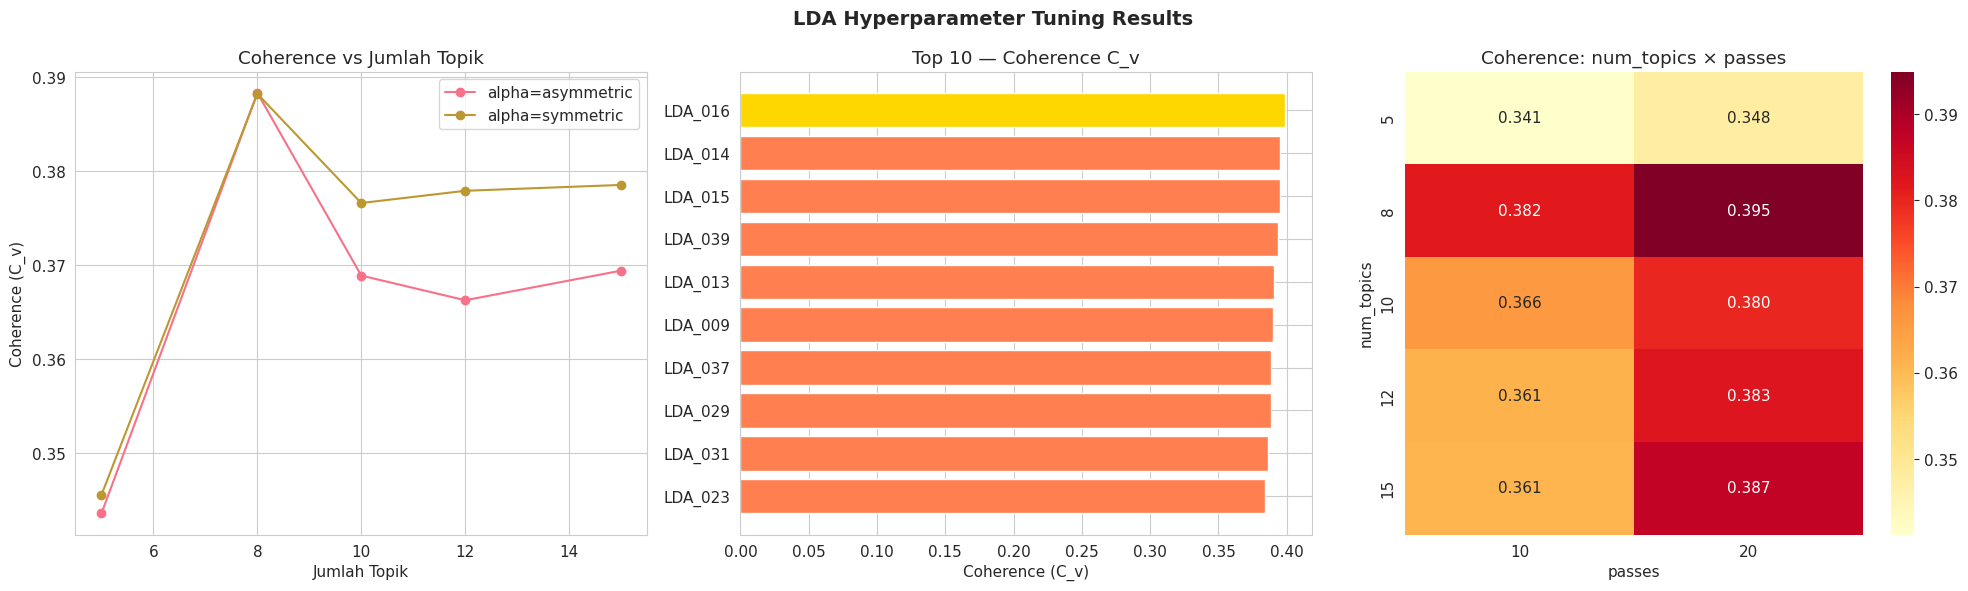

💾 Plot disimpan ke: step6_lda_tuning_results.png


In [52]:
# ============================================
# 6.3 Visualisasi LDA Tuning
# ============================================

if DATA_READY and len(df_lda_sorted) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("LDA Hyperparameter Tuning Results", fontsize=14, fontweight="bold")
    
    # 1. Coherence by num_topics
    ax1 = axes[0]
    for alpha_val in df_lda_sorted["alpha"].unique():
        subset = df_lda_sorted[df_lda_sorted["alpha"] == alpha_val]
        means = subset.groupby("num_topics")["coherence_cv"].mean()
        ax1.plot(means.index, means.values, marker='o', label=f"alpha={alpha_val}")
    ax1.set_xlabel("Jumlah Topik")
    ax1.set_ylabel("Coherence (C_v)")
    ax1.set_title("Coherence vs Jumlah Topik")
    ax1.legend()
    
    # 2. Top-10 bar chart
    ax2 = axes[1]
    top10_lda = df_lda_sorted.head(10)
    colors_lda = ["gold" if i == 0 else "coral" for i in range(len(top10_lda))]
    ax2.barh(top10_lda["run_id"][::-1], top10_lda["coherence_cv"][::-1], color=colors_lda[::-1])
    ax2.set_xlabel("Coherence (C_v)")
    ax2.set_title("Top 10 — Coherence C_v")
    
    # 3. Heatmap: num_topics vs passes
    ax3 = axes[2]
    pivot = df_lda_sorted.pivot_table(
        values="coherence_cv",
        index="num_topics",
        columns="passes",
        aggfunc="mean",
    )
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax3)
    ax3.set_title("Coherence: num_topics × passes")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step6_lda_tuning_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step6_lda_tuning_results.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 7. 🏋️ Training Model Terbaik

### Catatan training BERTopic final
- Representation memakai **MMR** (`diversity=0.3`) untuk merapikan kata representasi topik setelah c-TF-IDF.
- `reduce_outliers` dijalankan bertahap: `c-tf-idf` (threshold 0.1) lalu `distributions` (threshold 0.05) bila masih ada outlier.
- Setelah itu `update_topics` dipanggil ulang dengan vectorizer + representation yang sama agar representasi topik konsisten.

In [53]:
# ============================================
# 7.1 Training BERTopic dengan Parameter Terbaik
# ============================================

from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

if DATA_READY:
    print("🏋️ Training BERTopic Final Model dengan parameter terbaik...")

    show_cols = [
        "umap_n_neighbors",
        "umap_n_components",
        "umap_min_dist",
        "hdbscan_min_cluster_size",
        "hdbscan_min_samples",
        "min_topic_size",
        "nr_topics",
        "vectorizer_ngram_range",
        "vectorizer_min_df",
        "vectorizer_max_df",
    ]
    show_cols_existing = [c for c in show_cols if c in best_bt.index]
    if show_cols_existing:
        print(f"   Parameter: {best_bt[show_cols_existing].to_dict()}")

    start = time.time()

    nr_topics_raw = best_bt.get("nr_topics") if "nr_topics" in best_bt.index else None
    if nr_topics_raw is None or (isinstance(nr_topics_raw, float) and pd.isna(nr_topics_raw)):
        nr_topics_val = None
    elif isinstance(nr_topics_raw, str):
        nr_topics_val = nr_topics_raw
    else:
        nr_topics_val = int(nr_topics_raw)
    print(f"   nr_topics (hard cap/auto): {nr_topics_val}")

    best_umap = UMAP(
        n_neighbors=int(best_bt["umap_n_neighbors"]),
        n_components=int(best_bt["umap_n_components"]),
        min_dist=float(best_bt["umap_min_dist"]),
        metric=str(best_bt["umap_metric"]) if "umap_metric" in best_bt.index else "cosine",
        random_state=RANDOM_STATE,
    )

    best_hdbscan = HDBSCAN(
        min_cluster_size=int(best_bt["hdbscan_min_cluster_size"]),
        min_samples=(
            int(best_bt["hdbscan_min_samples"])
            if "hdbscan_min_samples" in best_bt.index and pd.notna(best_bt.get("hdbscan_min_samples"))
            else None
        ),
        metric=str(best_bt["hdbscan_metric"]) if "hdbscan_metric" in best_bt.index else "euclidean",
        cluster_selection_method=str(best_bt["hdbscan_method"]) if "hdbscan_method" in best_bt.index else "eom",
        prediction_data=True,
    )

    vec_ngram = best_bt.get("vectorizer_ngram_range") if "vectorizer_ngram_range" in best_bt.index else None
    if isinstance(vec_ngram, list):
        vec_ngram = tuple(vec_ngram)
    if not (isinstance(vec_ngram, tuple) and len(vec_ngram) == 2):
        vec_ngram = None

    vec_min_df = best_bt.get("vectorizer_min_df") if "vectorizer_min_df" in best_bt.index else None
    vec_max_df = best_bt.get("vectorizer_max_df") if "vectorizer_max_df" in best_bt.index else None

    best_vectorizer = build_vectorizer(
        stopword_list,
        min_df=vec_min_df,
        max_df=vec_max_df,
        ngram_range=vec_ngram,
    )
    print(
        "   Vectorizer: "
        f"min_df={best_vectorizer.min_df}, "
        f"max_df={best_vectorizer.max_df}, "
        f"ngram={best_vectorizer.ngram_range}"
    )

    from bertopic.representation import MaximalMarginalRelevance

    mmr_model = MaximalMarginalRelevance(diversity=0.3)
    print("   Representation: MMR (diversity=0.3)")

    final_bt_model = BERTopic(
        embedding_model=st_model,
        umap_model=best_umap,
        hdbscan_model=best_hdbscan,
        vectorizer_model=best_vectorizer,
        representation_model=mmr_model,
        top_n_words=int(CONFIG["top_n_words"]),
        min_topic_size=int(best_bt["min_topic_size"]),
        nr_topics=nr_topics_val,
        verbose=True,
    )

    bt_topics, bt_probs = final_bt_model.fit_transform(documents_cleaned, embeddings=embeddings)

    bt_duration = round(time.time() - start, 2)
    bt_topic_info = final_bt_model.get_topic_info()
    bt_num_topics = len(bt_topic_info) - 1
    bt_outliers_before = int((np.array(bt_topics) == -1).sum())

    print("\n📊 BERTopic sebelum reduce_outliers:")
    print(f"   Topik ditemukan : {bt_num_topics}")
    print(f"   Outliers        : {bt_outliers_before} ({bt_outliers_before/len(documents_cleaned)*100:.1f}%)")
    print(f"   Durasi          : {bt_duration}s")

    print("\n⏳ Menjalankan reduce_outliers...")

    bt_topics_reduced = final_bt_model.reduce_outliers(
        documents_cleaned,
        bt_topics,
        strategy="c-tf-idf",
        threshold=0.1,
    )
    outliers_after_ctfidf = int((np.array(bt_topics_reduced) == -1).sum())
    print(
        f"   Setelah c-TF-IDF      : {outliers_after_ctfidf} outliers "
        f"({outliers_after_ctfidf/len(documents_cleaned)*100:.1f}%)"
    )

    if outliers_after_ctfidf > 0:
        bt_topics_reduced = final_bt_model.reduce_outliers(
            documents_cleaned,
            bt_topics_reduced,
            strategy="distributions",
            threshold=0.05,
        )
        outliers_after_dist = int((np.array(bt_topics_reduced) == -1).sum())
        print(
            f"   Setelah distributions : {outliers_after_dist} outliers "
            f"({outliers_after_dist/len(documents_cleaned)*100:.1f}%)"
        )

    final_bt_model.update_topics(
        documents_cleaned,
        topics=bt_topics_reduced,
        vectorizer_model=best_vectorizer,
        representation_model=mmr_model,
    )
    bt_topics = bt_topics_reduced

    bt_topic_info = final_bt_model.get_topic_info()
    bt_num_topics = len(bt_topic_info) - 1
    bt_outliers = int((np.array(bt_topics) == -1).sum())

    print("\n✅ BERTopic final selesai!")
    print(f"   Topik final     : {bt_num_topics}")
    print(f"   Outliers awal   : {bt_outliers_before} ({bt_outliers_before/len(documents_cleaned)*100:.1f}%)")
    print(f"   Outliers final  : {bt_outliers} ({bt_outliers/len(documents_cleaned)*100:.1f}%)")
    print(f"   Durasi          : {bt_duration}s")

    bt_topic_info.to_csv(OUTPUT_CSV_DIR / "step7_bertopic_final_topic_info.csv", index=False)
    print("💾 Topic info disimpan ke: step7_bertopic_final_topic_info.csv")
    display(bt_topic_info.head(15))
else:
    print("⏭️ Langkah ini dilewati.")


2026-04-05 01:45:52,427 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


🏋️ Training BERTopic Final Model dengan parameter terbaik...
   Parameter: {'umap_n_neighbors': 55, 'umap_n_components': 5, 'umap_min_dist': 0.0, 'hdbscan_min_cluster_size': 8, 'hdbscan_min_samples': 1, 'min_topic_size': 12, 'nr_topics': 'auto', 'vectorizer_ngram_range': (1, 2), 'vectorizer_min_df': 2, 'vectorizer_max_df': 0.95}
   nr_topics (hard cap/auto): auto
   Vectorizer: min_df=2, max_df=0.95, ngram=(1, 2)
   Representation: MMR (diversity=0.3)


2026-04-05 01:45:53,501 - BERTopic - Dimensionality - Completed ✓
2026-04-05 01:45:53,502 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 01:45:53,517 - BERTopic - Cluster - Completed ✓
2026-04-05 01:45:53,518 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-05 01:46:20,878 - BERTopic - Representation - Completed ✓
2026-04-05 01:46:20,879 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 01:46:39,702 - BERTopic - Topic reduction - Reduced number of topics from 21 to 12



📊 BERTopic sebelum reduce_outliers:
   Topik ditemukan : 11
   Outliers        : 108 (22.8%)
   Durasi          : 47.42s

⏳ Menjalankan reduce_outliers...
   Setelah c-TF-IDF      : 5 outliers (1.1%)


100%|██████████| 1/1 [00:00<00:00, 117.30it/s]
2026-04-05 01:46:39,879 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


   Setelah distributions : 0 outliers (0.0%)

✅ BERTopic final selesai!
   Topik final     : 10
   Outliers awal   : 108 (22.8%)
   Outliers final  : 0 (0.0%)
   Durasi          : 47.42s
💾 Topic info disimpan ke: step7_bertopic_final_topic_info.csv


,Topic,Count,Name,Representation,Representative_Docs
0,0,296,0_pengujian_pengelolaan_waterfall_kabupaten,"[pengujian, pengelolaan, waterfall, kabupaten,...",[sistem informasi inventarisasi barang milik n...
1,1,39,1_performa_laravel_pengujian_server,"[performa, laravel, pengujian, server, kerenta...","[analisis perbandingan performa spring boot, f..."
2,2,23,2_edukasi_siswa_development life_pengembangan ...,"[edukasi, siswa, development life, pengembanga...","[game edukasi berbasis android ""math runner"" m..."
3,3,25,3_analisis sentimen_naïve bayes_naïve_klasifikasi,"[analisis sentimen, naïve bayes, naïve, klasif...",[analisis sentimen terhadap penggunaan video a...
4,4,14,4_screening_backpropagation_clustering_screeni...,"[screening, backpropagation, clustering, scree...",[analisis performa metode triple deep convolut...
5,5,15,5_produk_clustering_penjualan_algoritma means,"[produk, clustering, penjualan, algoritma mean...",[implementasi segmentasi nasabah pada pegadaia...
6,6,15,6_budaya_bumdes_algoritma genetika_ant colony,"[budaya, bumdes, algoritma genetika, ant colon...",[implementasi metode electre dalam sistem reko...
7,7,14,7_deteksi_isyarat_wajah_precision,"[deteksi, isyarat, wajah, precision, recogniti...",[model deep learning yolo v11 untuk deteksi ob...
8,8,14,8_pakar_hama_chaining_mobil,"[pakar, hama, chaining, mobil, pakar identifik...",[rancang bangun sistem pakar identifikasi peny...
9,9,10,9_kalori_klasifikasi_support vector_sehat,"[kalori, klasifikasi, support vector, sehat, l...",[prediksi pertandingan mixed martial arts pada...


In [54]:
# ============================================
# 7.2 Training LDA dengan Parameter Terbaik
# ============================================

if DATA_READY:
    print("🏋️ Training LDA Final Model dengan parameter terbaik...")
    print(f"   Parameter: num_topics={best_lda['num_topics']}, passes={best_lda['passes']}, alpha={best_lda['alpha']}, eta={best_lda['eta']}")
    
    start = time.time()
    
    # Build dictionary & corpus
    final_lda_dict = Dictionary(tokenized_docs_lda)
    no_below = int(best_lda.get("no_below", 2))
    no_above = float(best_lda.get("no_above", 0.95))
    final_lda_dict.filter_extremes(no_below=no_below, no_above=no_above)
    if len(final_lda_dict) == 0:
        raise ValueError("Dictionary kosong setelah filter_extremes (coba turunkan no_below / naikkan no_above)")
    final_lda_corpus = [final_lda_dict.doc2bow(doc) for doc in tokenized_docs_lda]
    
    # Train
    iterations = int(best_lda.get("iterations", 400))
    rs = int(best_lda.get("random_state", RANDOM_STATE))
    alpha = best_lda["alpha"]
    eta = best_lda["eta"]
    use_multicore = (alpha != "auto") and (eta != "auto")
    if use_multicore:
        final_lda_model = LdaMulticore(
            corpus=final_lda_corpus,
            id2word=final_lda_dict,
            num_topics=int(best_lda["num_topics"]),
            passes=int(best_lda["passes"]),
            iterations=iterations,
            chunksize=100,
            random_state=rs,
            alpha=alpha,
            eta=eta,
            per_word_topics=True,
        )
    else:
        final_lda_model = LdaModel(
            corpus=final_lda_corpus,
            id2word=final_lda_dict,
            num_topics=int(best_lda["num_topics"]),
            passes=int(best_lda["passes"]),
            iterations=iterations,
            random_state=rs,
            alpha=alpha,
            eta=eta,
            per_word_topics=True,
        )
    
    lda_duration = round(time.time() - start, 2)
    
    # Extract topic words
    lda_topic_records = []
    for tid in range(int(best_lda["num_topics"])):
        words_scores = final_lda_model.show_topic(tid, topn=CONFIG["top_n_words"])
        lda_topic_records.append({
            "topic_id": tid,
            "top_words": ", ".join([w for w, _ in words_scores]),
            "word_scores": ", ".join([f"{s:.4f}" for _, s in words_scores]),
        })
    
    df_lda_topics = pd.DataFrame(lda_topic_records)
    df_lda_topics.to_csv(OUTPUT_CSV_DIR / "step7_lda_final_topic_info.csv", index=False)
    
    print(f"\n✅ LDA Final Model selesai!")
    print(f"   Topik           : {int(best_lda['num_topics'])}")
    print(f"   Dictionary size : {len(final_lda_dict)}")
    print(f"   Durasi          : {lda_duration}s")
    print(f"💾 Topic info disimpan ke: step7_lda_final_topic_info.csv")
    display(df_lda_topics)
else:
    print("⏭️ Langkah ini dilewati.")

🏋️ Training LDA Final Model dengan parameter terbaik...
   Parameter: num_topics=8, passes=20, alpha=asymmetric, eta=None

✅ LDA Final Model selesai!
   Topik           : 8
   Dictionary size : 2570
   Durasi          : 3.59s
💾 Topic info disimpan ke: step7_lda_final_topic_info.csv


,topic_id,top_words,word_scores
0,0,"nilai, guna, analisis, hasil, model, sentimen,...","0.0183, 0.0143, 0.0136, 0.0136, 0.0131, 0.0106..."
1,1,"aplikasi, kembang, guna, tingkat, uji, perform...","0.0302, 0.0180, 0.0172, 0.0128, 0.0121, 0.0116..."
2,2,"game, ajar, model, edukasi, nilai, kembang, uj...","0.0434, 0.0236, 0.0159, 0.0151, 0.0150, 0.0145..."
3,3,"model, nilai, prediksi, hasil, tingkat, implem...","0.0357, 0.0251, 0.0143, 0.0137, 0.0120, 0.0102..."
4,4,"informasi, uji, kembang, bas, kelola, kerja, a...","0.0244, 0.0215, 0.0166, 0.0160, 0.0153, 0.0151..."
5,5,"informasi, barang, bas, kelola, bangun, kemban...","0.0370, 0.0186, 0.0185, 0.0174, 0.0172, 0.0156..."
6,6,"informasi, jual, bas, kembang, aplikasi, mesan...","0.0289, 0.0163, 0.0135, 0.0132, 0.0128, 0.0126..."
7,7,"pakar, kembang, sakit, uji, bantu, bas, desa, ...","0.0192, 0.0163, 0.0158, 0.0131, 0.0128, 0.0127..."


---
## 8. 📏 Evaluasi & Perbandingan Model

In [55]:
# ============================================
# 8.1 Evaluasi & Perbandingan (BERTopic vs LDA)
# ============================================

if DATA_READY:
    from gensim.corpora import Dictionary

    coherence_type = str(CONFIG.get("coherence_type", "c_v"))
    top_n_words = int(CONFIG["top_n_words"])

    # --- BERTopic: topic words + coherence + diversity ---
    bt_topic_words = bertopic_topic_words(final_bt_model, top_n_words=top_n_words)

    coherence_tokenization = str(CONFIG.get("coherence_tokenization", "vectorizer")).strip().lower()
    if coherence_tokenization != "vectorizer":
        print(f"⚠️ coherence_tokenization={coherence_tokenization} diabaikan. Dipaksa ke 'vectorizer' agar konsisten.")
        coherence_tokenization = "vectorizer"

    vectorizer_for_cv = best_vectorizer if "best_vectorizer" in globals() and best_vectorizer is not None else build_vectorizer(stopword_list)
    analyzer = vectorizer_for_cv.build_analyzer()
    tokenized_for_cv = [analyzer(doc) for doc in documents_cleaned]
    dictionary_for_cv = Dictionary(tokenized_for_cv)
    dictionary_for_cv.filter_extremes(
        no_below=int(CONFIG.get("coherence_dict_no_below", 3)),
        no_above=float(CONFIG.get("coherence_dict_no_above", 0.95)),
    )

    bt_final_coherence = coherence_score_cv(
        bt_topic_words,
        tokenized_texts=tokenized_for_cv,
        dictionary=dictionary_for_cv,
        coherence=coherence_type,
    )
    bt_final_diversity = topic_diversity(bt_topic_words, top_n_words=top_n_words)

    # --- LDA: coherence + diversity ---
    from gensim.models.coherencemodel import CoherenceModel

    lda_cm = CoherenceModel(
        model=final_lda_model,
        texts=tokenized_docs_lda,
        dictionary=final_lda_dict,
        coherence=coherence_type,
    )
    lda_final_coherence = round(lda_cm.get_coherence(), 4)

    lda_tw = lda_topic_words(
        final_lda_model,
        num_topics=int(best_lda["num_topics"]),
        top_n_words=top_n_words,
    )
    lda_final_diversity = topic_diversity(lda_tw, top_n_words=top_n_words)

    # --- Tabel Perbandingan ---
    comparison = pd.DataFrame({
        "Metrik": [
            "Model",
            "Embedding",
            "Jumlah Topik",
            f"Coherence ({coherence_type}) ↑",
            "Topic Diversity ↑",
            "Outliers",
            "Durasi Training (s)",
        ],
        "BERTopic": [
            "BERTopic (IndoSBERT → UMAP → HDBSCAN → c-TF-IDF + MMR)",
            f"{CONFIG['embedding_model']} (256-dim output)",
            bt_num_topics,
            bt_final_coherence,
            bt_final_diversity,
            f"{bt_outliers} ({bt_outliers/len(documents_cleaned)*100:.1f}%) [sebelum reduce: {bt_outliers_before}]",
            bt_duration,
        ],
        "LDA": [
            "LDA (Gensim LdaMulticore)",
            "Bag-of-Words (TF)",
            int(best_lda["num_topics"]),
            lda_final_coherence,
            lda_final_diversity,
            "N/A",
            lda_duration,
        ],
    })

    comparison.to_csv(OUTPUT_CSV_DIR / "step8_model_comparison.csv", index=False)
    print("💾 Perbandingan disimpan ke: step8_model_comparison.csv\n")
    print("📊 PERBANDINGAN BERTopic vs LDA:")
    display(comparison)

    coherence_winner = "BERTopic" if bt_final_coherence > lda_final_coherence else "LDA"
    diversity_winner = "BERTopic" if bt_final_diversity > lda_final_diversity else "LDA"
    print(f"\n🏆 Coherence Winner  : {coherence_winner} (diff={abs(bt_final_coherence - lda_final_coherence):.4f})")
    print(f"🏆 Diversity Winner  : {diversity_winner} (diff={abs(bt_final_diversity - lda_final_diversity):.4f})")
else:
    print("⏭️ Langkah ini dilewati.")

💾 Perbandingan disimpan ke: step8_model_comparison.csv

📊 PERBANDINGAN BERTopic vs LDA:


,Metrik,BERTopic,LDA
0,Model,BERTopic (IndoSBERT → UMAP → HDBSCAN → c-TF-ID...,LDA (Gensim LdaMulticore)
1,Embedding,denaya/indoSBERT-large (256-dim output),Bag-of-Words (TF)
2,Jumlah Topik,10,8
3,Coherence (c_v) ↑,0.4616,0.3986
4,Topic Diversity ↑,0.9364,0.55
5,Outliers,0 (0.0%) [sebelum reduce: 108],N/A
6,Durasi Training (s),47.42,3.59



🏆 Coherence Winner  : BERTopic (diff=0.0630)
🏆 Diversity Winner  : BERTopic (diff=0.3864)


In [56]:
# ============================================
# 8.1a Sanity Check — CV Tuning vs CV Final
# ============================================

if DATA_READY:
    try:
        cv_tuning = float(best_bt.get("coherence_cv"))
    except Exception:
        cv_tuning = float("nan")

    try:
        cv_final = float(bt_final_coherence)
    except Exception:
        cv_final = float("nan")

    print("🔎 Sanity check coherence:")
    print(f"   CV (tuning best_bt) : {cv_tuning}")
    print(f"   CV (final_bt_model) : {cv_final}")
    if (not pd.isna(cv_tuning)) and (not pd.isna(cv_final)):
        print(f"   Δ (final - tuning)  : {cv_final - cv_tuning:+.4f}")
else:
    print("⏭️ Langkah ini dilewati.")


🔎 Sanity check coherence:
   CV (tuning best_bt) : 0.4616
   CV (final_bt_model) : 0.4616
   Δ (final - tuning)  : +0.0000


In [57]:
# ============================================
# 8.1b Sanity Check — Konsistensi C_v (satu sumber kebenaran)
# ============================================

if DATA_READY:
    # Angka resmi yang dipakai untuk report/plot adalah `bt_final_coherence` (dihitung di 8.1).
    coherence_tokenization = "vectorizer"

    try:
        cv_reported = float(bt_final_coherence)
    except Exception:
        cv_reported = float("nan")

    print("🔎 Coherence (C_v) yang dipakai untuk report:")
    print(f"   coherence_tokenization : {coherence_tokenization}")
    print("   standar tokenisasi    : analyzer CountVectorizer (selaras c-TF-IDF + MMR)")
    print(f"   CV (final_bt_model, reported) : {cv_reported:.4f}" if not pd.isna(cv_reported) else "   CV (final_bt_model, reported) : nan")
else:
    print("⏭️ Langkah ini dilewati.")

🔎 Coherence (C_v) yang dipakai untuk report:
   coherence_tokenization : vectorizer
   standar tokenisasi    : analyzer CountVectorizer (selaras c-TF-IDF + MMR)
   CV (final_bt_model, reported) : 0.4616


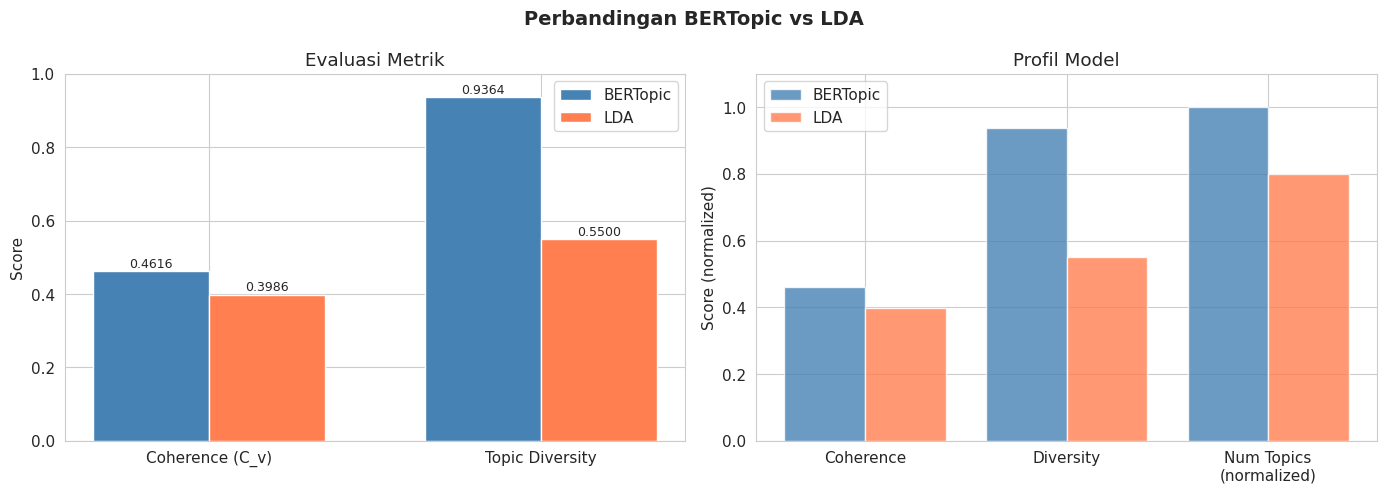

💾 Plot disimpan ke: step8_model_comparison.png


In [58]:
# ============================================
# 8.2 Visualisasi Perbandingan
# ============================================

if DATA_READY:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Perbandingan BERTopic vs LDA", fontsize=14, fontweight="bold")
    
    # 1. Bar chart: Coherence & Diversity
    ax1 = axes[0]
    metrics_names = ["Coherence (C_v)", "Topic Diversity"]
    bt_vals = [bt_final_coherence, bt_final_diversity]
    lda_vals = [lda_final_coherence, lda_final_diversity]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    bars1 = ax1.bar(x - width/2, bt_vals, width, label="BERTopic", color="steelblue")
    bars2 = ax1.bar(x + width/2, lda_vals, width, label="LDA", color="coral")
    
    ax1.set_ylabel("Score")
    ax1.set_title("Evaluasi Metrik")
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_names)
    ax1.legend()
    ax1.set_ylim(0, 1)
    
    # Annotate
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.4f}", ha='center', fontsize=9)
    for bar in bars2:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.4f}", ha='center', fontsize=9)
    
    # 2. Radar-style comparison (simple)
    ax2 = axes[1]
    categories = ["Coherence", "Diversity", "Num Topics\n(normalized)"]
    max_topics = max(bt_num_topics, int(best_lda["num_topics"]))
    bt_radar = [bt_final_coherence, bt_final_diversity, bt_num_topics / max_topics]
    lda_radar = [lda_final_coherence, lda_final_diversity, int(best_lda["num_topics"]) / max_topics]
    
    x_pos = np.arange(len(categories))
    ax2.bar(x_pos - 0.2, bt_radar, 0.4, label="BERTopic", color="steelblue", alpha=0.8)
    ax2.bar(x_pos + 0.2, lda_radar, 0.4, label="LDA", color="coral", alpha=0.8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(categories)
    ax2.set_ylabel("Score (normalized)")
    ax2.set_title("Profil Model")
    ax2.legend()
    ax2.set_ylim(0, 1.1)
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step8_model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step8_model_comparison.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 9. 📈 Dynamic Topic Analysis (DTA) — Evolusi Topik per Tahun

In [59]:
# ============================================
# 9.1 BERTopic — Topics Over Time
# ============================================

if DATA_READY and "year" in df_processed.columns:
    timestamps = df_processed["year"].tolist()
    
    print("📈 Menjalankan Dynamic Topic Analysis (BERTopic topics_over_time)...")
    topics_over_time = final_bt_model.topics_over_time(
        documents_cleaned,
        timestamps=timestamps,
    )
    
    # Simpan ke CSV
    topics_over_time.to_csv(OUTPUT_CSV_DIR / "step9_topics_over_time.csv", index=False)
    print(f"✅ Topics over time: {len(topics_over_time)} records")
    print(f"💾 Disimpan ke: step9_topics_over_time.csv")
    display(topics_over_time.head(20))
else:
    print("⏭️ Langkah ini dilewati (data atau kolom year tidak tersedia).")

📈 Menjalankan Dynamic Topic Analysis (BERTopic topics_over_time)...


9it [01:59, 13.25s/it]

✅ Topics over time: 67 records
💾 Disimpan ke: step9_topics_over_time.csv


,Topic,Words,Frequency,Timestamp
0,0,"berbasis web, pengelolaan, pengujian, pendukun...",37,2018
1,1,"mesin, pakar identifikasi, chaining, bangun pa...",1,2018
2,2,"build, aplikasi rekomendasi, permainan, selesa...",1,2018
3,4,"gas, daerah, informasi geografis, penyakit, induk",1,2018
4,6,"budaya, based service, menginap, kabupaten ban...",1,2018
5,8,"kelinci, forward chaining, tulang, identifikas...",3,2018
6,10,"keamanan informasi, audit, xyz, pengelolaan, a...",3,2018
7,0,"berbasis web, pemrograman php, pengelolaan, my...",32,2019
8,3,"barang, steam, market, syaraf tiruan, jual beli",1,2019
9,5,"membership, tata letak, produk, produksi, fasi...",2,2019


In [60]:
# ============================================
# 9.2 Trend Analysis — Emerging, Declining, Stable
# ============================================

if DATA_READY and "year" in df_processed.columns:
    from scipy import stats as scipy_stats
    
    # Analisis tren per topik
    trend_records = []
    
    for topic_id in topics_over_time["Topic"].unique():
        if topic_id == -1:
            continue
        
        topic_data = topics_over_time[topics_over_time["Topic"] == topic_id].copy()
        topic_data = topic_data.sort_values("Timestamp")
        
        if len(topic_data) < 2:
            continue
        
        # Linear regression untuk menentukan tren
        years_numeric = pd.to_numeric(topic_data["Timestamp"].astype(str).str[:4], errors='coerce')
        if years_numeric.isna().all():
            years_numeric = np.arange(len(topic_data))
        
        frequencies = topic_data["Frequency"].values
        
        if len(years_numeric) >= 2:
            slope, intercept, r_val, p_val, std_err = scipy_stats.linregress(
                years_numeric.values, frequencies
            )
        else:
            slope, r_val, p_val = 0, 0, 1
        
        # Klasifikasi tren
        if slope > 0.5 and p_val < 0.3:
            trend = "emerging"
        elif slope < -0.5 and p_val < 0.3:
            trend = "declining"
        else:
            trend = "stable"
        
        # Get topic words
        words = topic_data["Words"].iloc[0] if "Words" in topic_data.columns else ""
        
        trend_records.append({
            "topic_id": topic_id,
            "top_words": words,
            "trend": trend,
            "slope": round(slope, 4),
            "r_squared": round(r_val**2, 4),
            "p_value": round(p_val, 4),
            "avg_frequency": round(frequencies.mean(), 2),
            "min_frequency": int(frequencies.min()),
            "max_frequency": int(frequencies.max()),
        })
    
    df_trends = pd.DataFrame(trend_records)
    df_trends.to_csv(OUTPUT_CSV_DIR / "step9_topic_trends.csv", index=False)
    
    print("📈 Hasil Analisis Tren Topik:")
    print(f"   Emerging  : {len(df_trends[df_trends['trend'] == 'emerging'])} topik")
    print(f"   Declining : {len(df_trends[df_trends['trend'] == 'declining'])} topik")
    print(f"   Stable    : {len(df_trends[df_trends['trend'] == 'stable'])} topik")
    print(f"\n💾 Disimpan ke: step9_topic_trends.csv")
    display(df_trends)
else:
    print("⏭️ Langkah ini dilewati.")

📈 Hasil Analisis Tren Topik:
   Emerging  : 3 topik
   Declining : 0 topik
   Stable    : 8 topik

💾 Disimpan ke: step9_topic_trends.csv


,topic_id,top_words,trend,slope,r_squared,p_value,avg_frequency,min_frequency,max_frequency
0,0,"berbasis web, pengelolaan, pengujian, pendukun...",stable,-0.4833,0.0174,0.7354,32.89,13,43
1,1,"mesin, pakar identifikasi, chaining, bangun pa...",emerging,1.5514,0.3606,0.1155,4.88,1,21
2,2,"build, aplikasi rekomendasi, permainan, selesa...",emerging,0.8689,0.6352,0.0319,3.29,1,7
3,4,"gas, daerah, informasi geografis, penyakit, induk",stable,0.1245,0.0586,0.6440,2.33,1,5
4,6,"budaya, based service, menginap, kabupaten ban...",stable,0.0714,0.0208,0.7575,2.14,1,4
5,8,"kelinci, forward chaining, tulang, identifikas...",stable,-0.1115,0.1895,0.3883,2.33,1,3
6,10,"keamanan informasi, audit, xyz, pengelolaan, a...",stable,-0.3571,0.8929,0.2123,2.67,2,3
7,3,"barang, steam, market, syaraf tiruan, jual beli",stable,0.3235,0.0476,0.6781,4.17,1,10
8,5,"membership, tata letak, produk, produksi, fasi...",emerging,0.8462,0.7850,0.1140,3.75,1,6
9,7,"syaraf tiruan, tiruan model, pengolahan citra,...",stable,0.8462,0.4329,0.3420,3.50,1,9


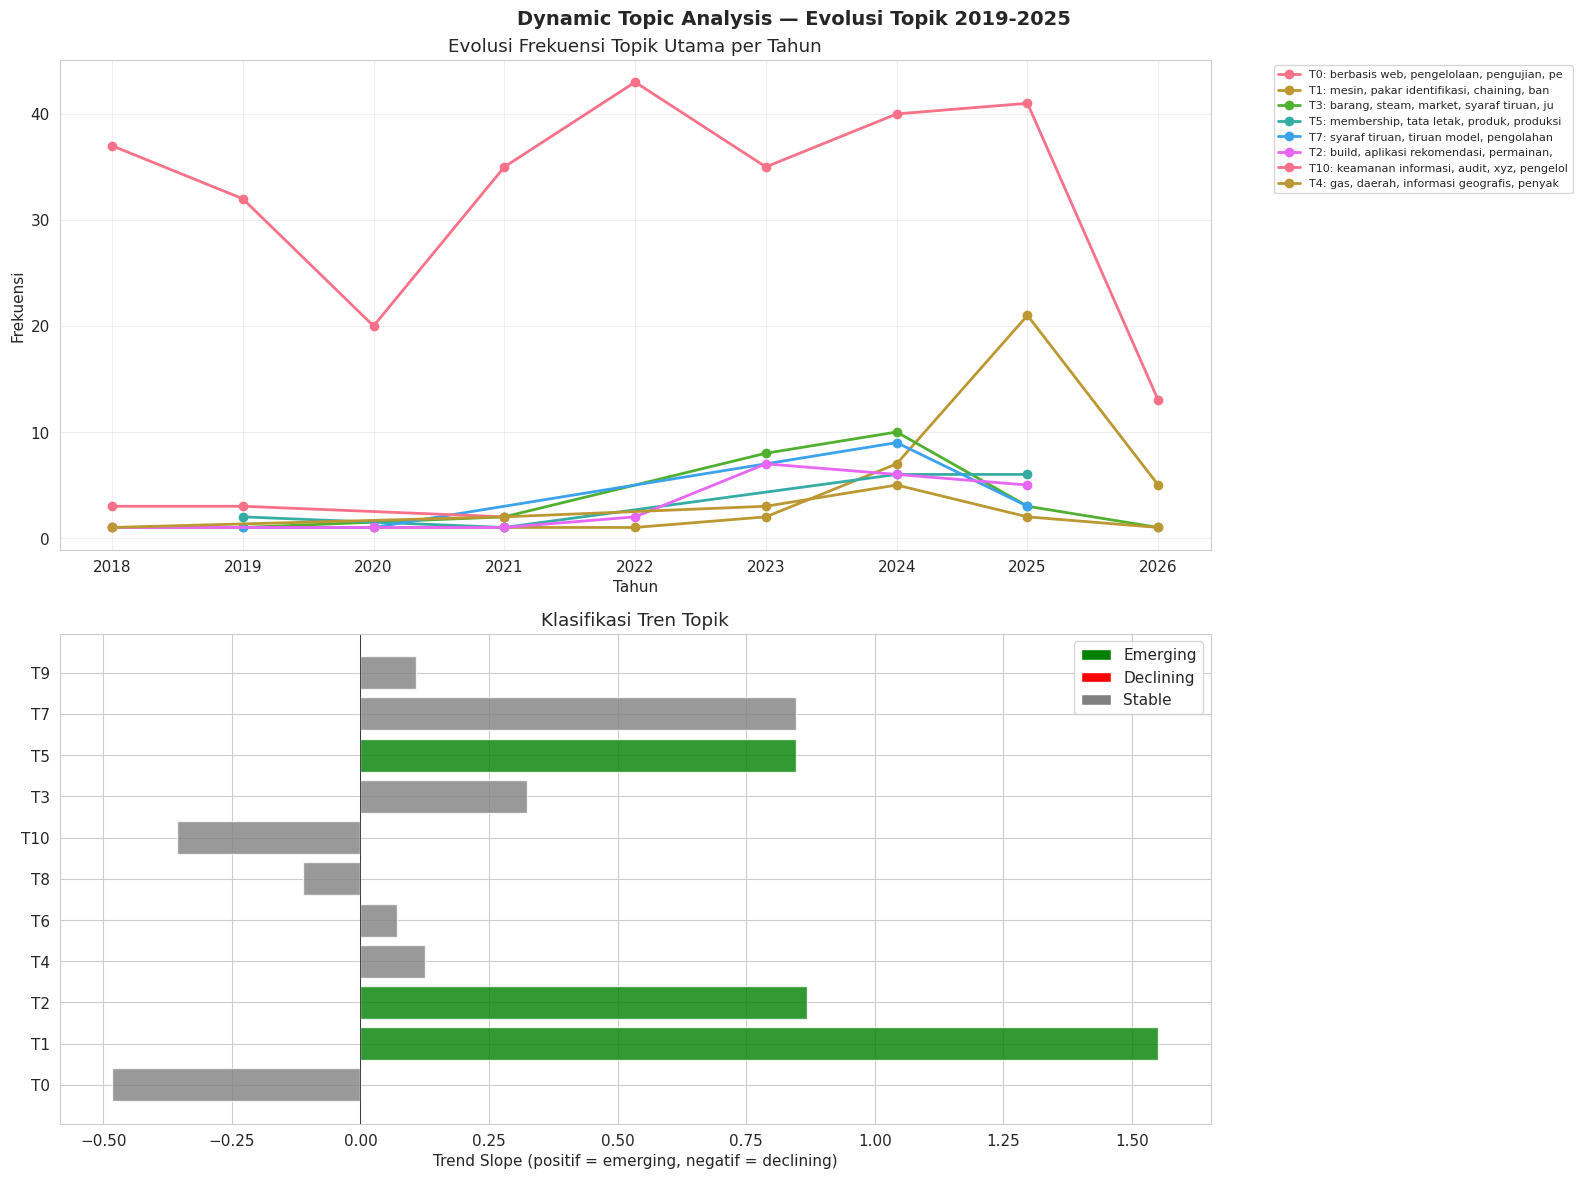

💾 Plot disimpan ke: step9_dynamic_topic_analysis.png


In [61]:
# ============================================
# 9.3 Visualisasi DTA
# ============================================

if DATA_READY and "year" in df_processed.columns and len(trend_records) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle("Dynamic Topic Analysis — Evolusi Topik 2019-2025", fontsize=14, fontweight="bold")
    
    # 1. Topics over time (line chart)
    ax1 = axes[0]
    # Ambil top-N topik berdasarkan rata-rata frekuensi
    top_topics = df_trends.nlargest(8, "avg_frequency")["topic_id"].tolist()
    
    for tid in top_topics:
        t_data = topics_over_time[topics_over_time["Topic"] == tid].sort_values("Timestamp")
        label_words = t_data["Words"].iloc[0][:40] if "Words" in t_data.columns else f"Topic {tid}"
        years_plot = pd.to_numeric(t_data["Timestamp"].astype(str).str[:4], errors='coerce')
        ax1.plot(years_plot, t_data["Frequency"].values, marker='o', linewidth=2, label=f"T{tid}: {label_words}")
    
    ax1.set_xlabel("Tahun")
    ax1.set_ylabel("Frekuensi")
    ax1.set_title("Evolusi Frekuensi Topik Utama per Tahun")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Trend classification bar
    ax2 = axes[1]
    trend_colors = {"emerging": "green", "declining": "red", "stable": "gray"}
    colors_trend = [trend_colors.get(t, "gray") for t in df_trends["trend"]]
    ax2.barh(
        [f"T{r['topic_id']}" for _, r in df_trends.iterrows()],
        df_trends["slope"],
        color=colors_trend,
        alpha=0.8
    )
    ax2.axvline(x=0, color='black', linewidth=0.5)
    ax2.set_xlabel("Trend Slope (positif = emerging, negatif = declining)")
    ax2.set_title("Klasifikasi Tren Topik")
    
    # Legend manual
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', label='Emerging'),
        Patch(facecolor='red', label='Declining'),
        Patch(facecolor='gray', label='Stable'),
    ]
    ax2.legend(handles=legend_elements)
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step9_dynamic_topic_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step9_dynamic_topic_analysis.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 10. ☁️ Word Cloud & Visualisasi Topik

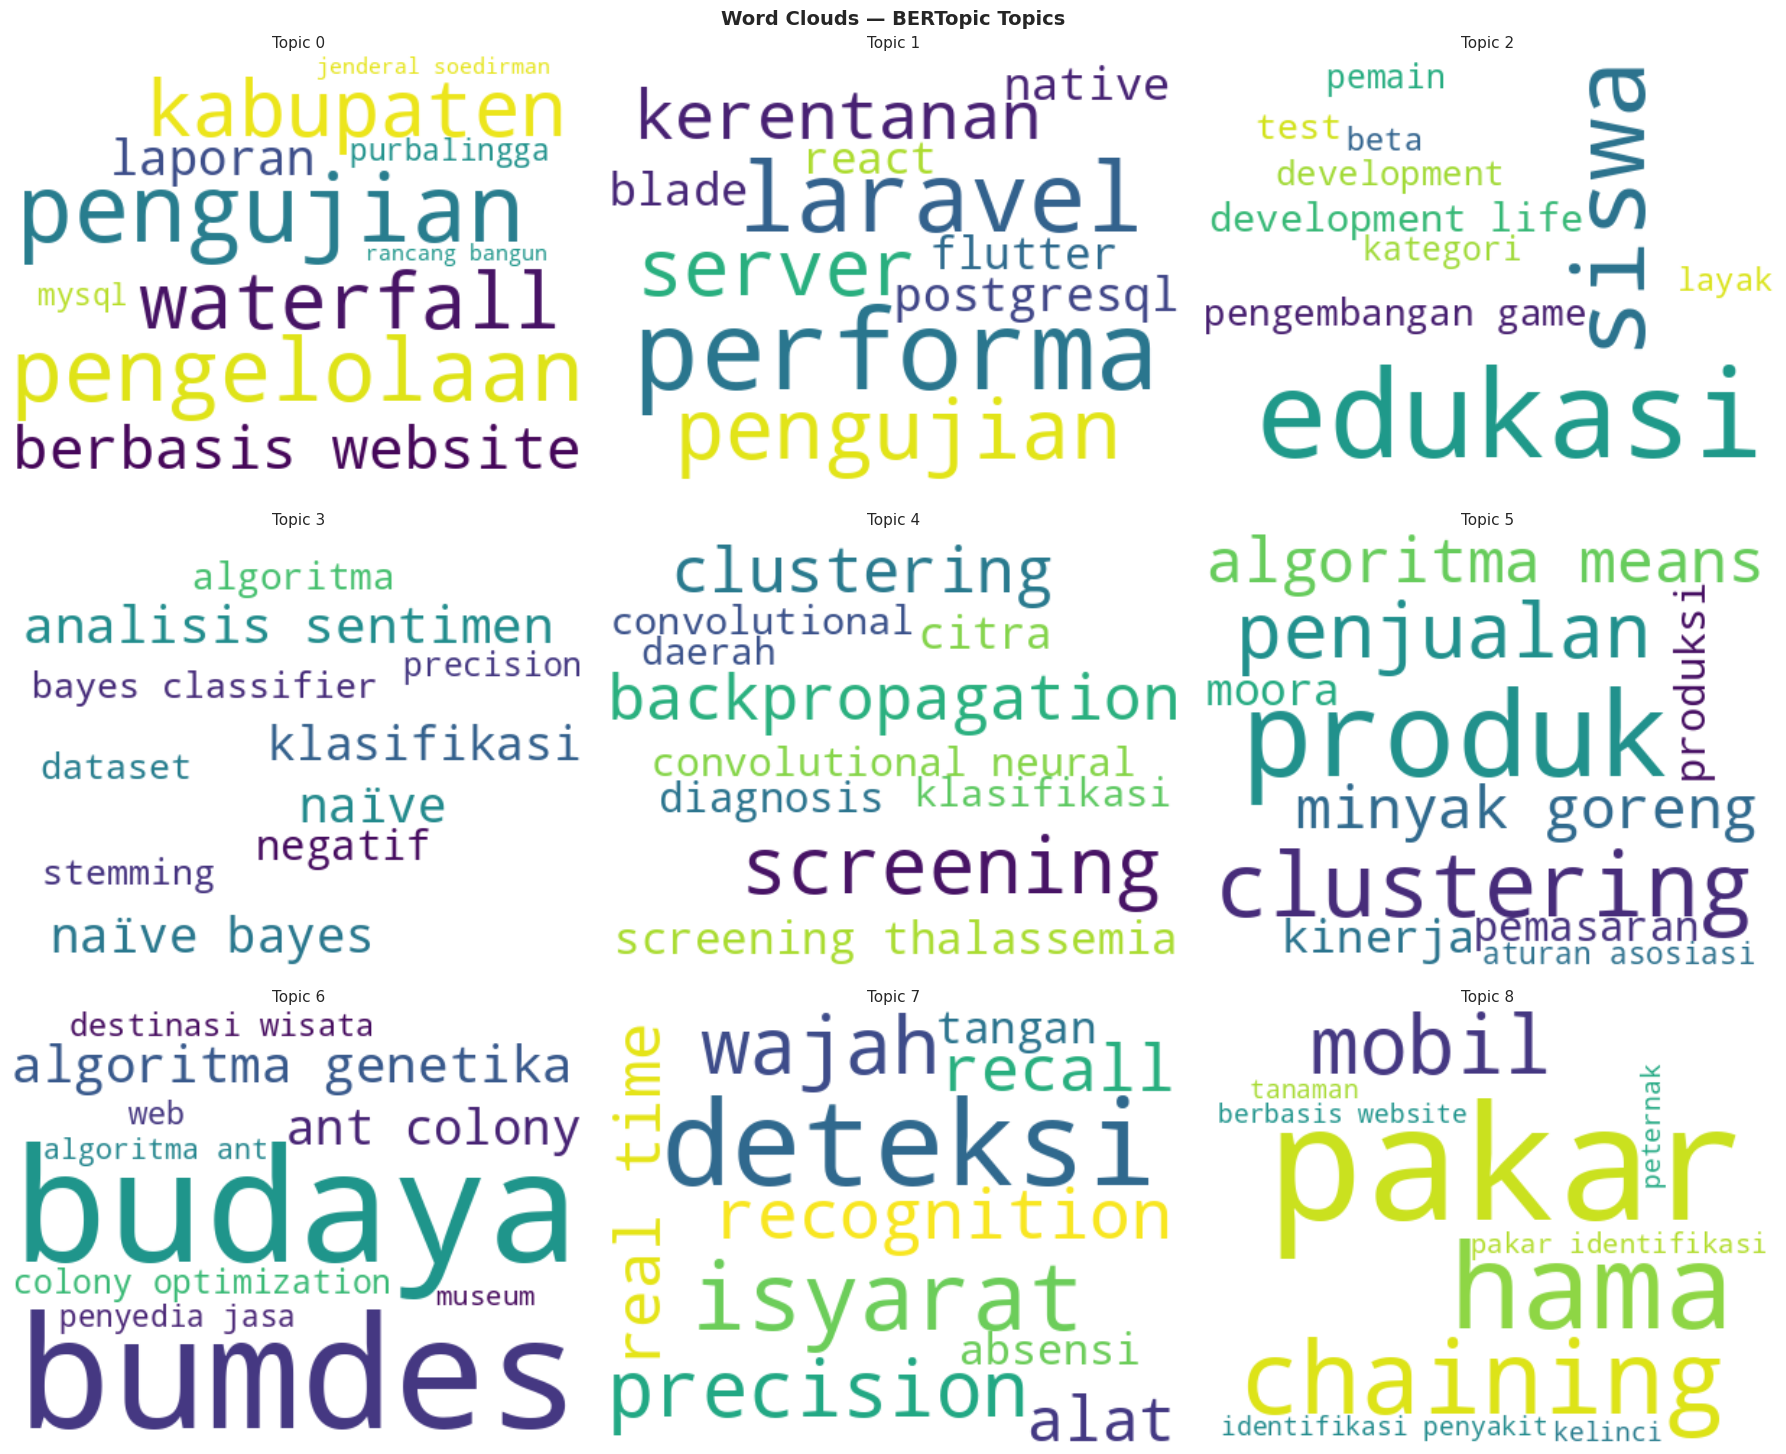

💾 Word clouds disimpan ke: step10_wordclouds_bertopic.png


In [62]:
# ============================================
# 10.1 Word Cloud per Topik (BERTopic)
# ============================================

if DATA_READY:
    from wordcloud import WordCloud
    
    # Ambil topik-topik (exclude outlier -1)
    all_topic_ids = [tid for tid in final_bt_model.get_topics() if tid != -1]
    n_topics_to_show = min(len(all_topic_ids), 9)  # max 9 untuk grid 3x3
    top_topic_ids = all_topic_ids[:n_topics_to_show]
    
    cols = 3
    rows = (n_topics_to_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    fig.suptitle("Word Clouds — BERTopic Topics", fontsize=14, fontweight="bold")
    
    if rows == 1:
        axes = [axes]
    
    for i, tid in enumerate(top_topic_ids):
        row_idx = i // cols
        col_idx = i % cols
        ax = axes[row_idx][col_idx] if rows > 1 else axes[0][col_idx]
        
        words_scores = final_bt_model.get_topic(tid)
        word_freq = {w: abs(s) for w, s in words_scores if w.strip()}
        
        if word_freq:
            wc = WordCloud(
                width=400, height=300,
                background_color="white",
                colormap="viridis",
                max_words=30,
            ).generate_from_frequencies(word_freq)
            ax.imshow(wc, interpolation="bilinear")
        
        ax.set_title(f"Topic {tid}", fontsize=11)
        ax.axis("off")
    
    # Hide empty subplots
    for i in range(n_topics_to_show, rows * cols):
        row_idx = i // cols
        col_idx = i % cols
        ax = axes[row_idx][col_idx] if rows > 1 else axes[0][col_idx]
        ax.axis("off")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step10_wordclouds_bertopic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Word clouds disimpan ke: step10_wordclouds_bertopic.png")
else:
    print("⏭️ Langkah ini dilewati.")

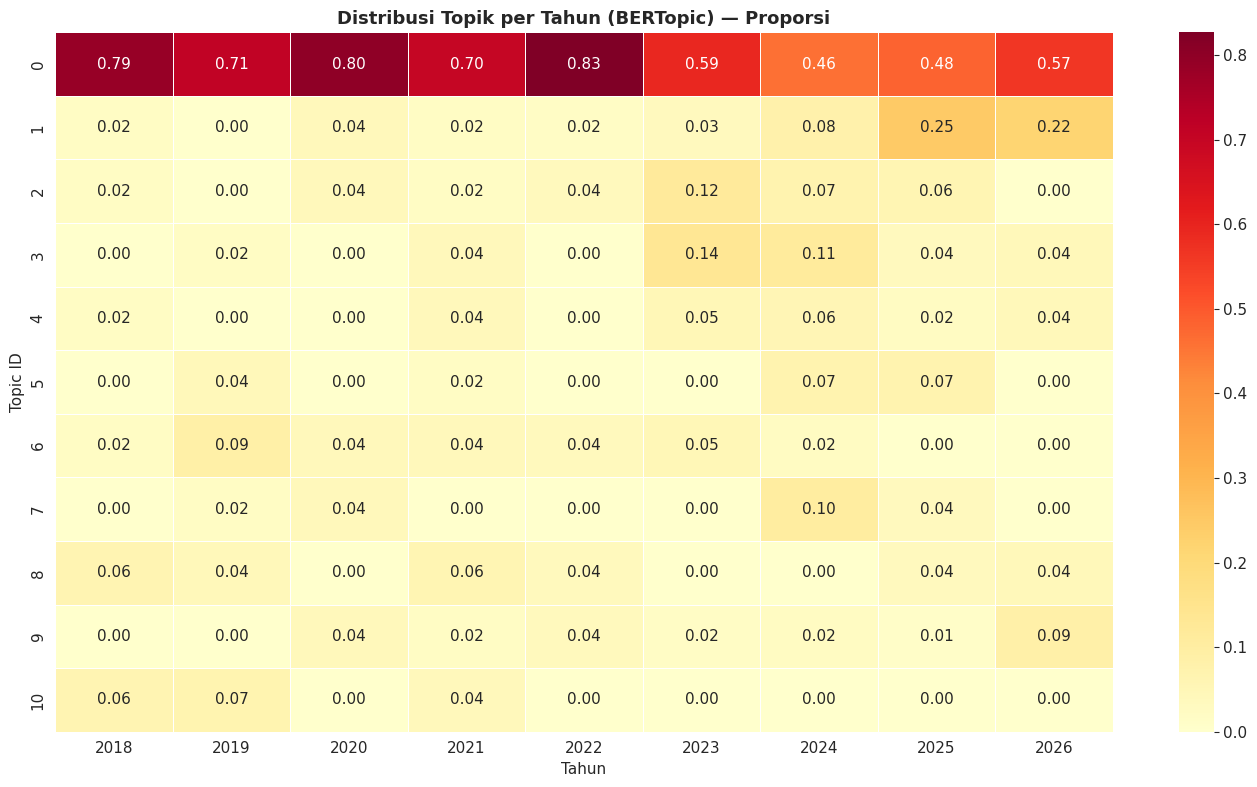

💾 Heatmap disimpan ke: step10_topic_year_heatmap.png
💾 Data disimpan ke: step10_topic_year_distribution.csv


In [63]:
# ============================================
# 10.2 Topic Distribution per Tahun (Heatmap)
# ============================================

if DATA_READY and "year" in df_processed.columns:
    # Buat distribusi topik per tahun dari BERTopic
    df_topic_year = pd.DataFrame({
        "year": df_processed["year"].values,
        "topic": bt_topics,
    })
    
    # Exclude outliers
    df_topic_year = df_topic_year[df_topic_year["topic"] != -1]
    
    # Cross-tabulation
    cross_tab = pd.crosstab(df_topic_year["topic"], df_topic_year["year"], normalize="columns")
    
    # Simpan
    cross_tab.to_csv(OUTPUT_CSV_DIR / "step10_topic_year_distribution.csv")
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(14, max(8, len(cross_tab) * 0.5)))
    sns.heatmap(
        cross_tab, annot=True, fmt=".2f", cmap="YlOrRd",
        linewidths=0.5, ax=ax
    )
    ax.set_title("Distribusi Topik per Tahun (BERTopic) — Proporsi", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Topic ID")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step10_topic_year_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Heatmap disimpan ke: step10_topic_year_heatmap.png")
    print("💾 Data disimpan ke: step10_topic_year_distribution.csv")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 11. 💾 Simpan Model & Ringkasan Akhir

In [64]:
# ============================================
# 11.1 Simpan Model BERTopic
# ============================================

if DATA_READY:
    bt_model_path = OUTPUT_MODEL_DIR / "bertopic_best_model"
    bt_model_path.mkdir(parents=True, exist_ok=True)

    # Helper lokal: konversi numpy/pandas scalar → Python built-in agar json.dump tidak gagal
    def _to_py(obj):
        try:
            import numpy as _np

            if isinstance(obj, _np.generic):
                return obj.item()
        except Exception:
            pass

        try:
            import pandas as _pd

            if obj is _pd.NA:
                return None
        except Exception:
            pass

        if isinstance(obj, (list, tuple)):
            return type(obj)(_to_py(v) for v in obj)
        if isinstance(obj, dict):
            return {k: _to_py(v) for k, v in obj.items()}
        return obj

    # Coerce vectorizer params & vocab (ini sumber umum error: np.int64 tidak JSON serializable)
    try:
        cv = getattr(final_bt_model, "vectorizer_model", None)
        if cv is not None:
            # params
            params = cv.get_params(deep=False)
            params = {k: _to_py(v) for k, v in params.items()}
            cv.set_params(**params)

            # vocabulary_ (token -> index)
            if hasattr(cv, "vocabulary_") and isinstance(cv.vocabulary_, dict):
                cv.vocabulary_ = {str(k): int(_to_py(v)) for k, v in cv.vocabulary_.items()}

            # ngram_range/min_df/max_df attributes (keep consistent)
            if hasattr(cv, "ngram_range") and cv.ngram_range is not None:
                cv.ngram_range = tuple(int(_to_py(v)) for v in cv.ngram_range)
            if hasattr(cv, "min_df"):
                cv.min_df = _to_py(cv.min_df)
            if hasattr(cv, "max_df"):
                cv.max_df = _to_py(cv.max_df)
    except Exception as _e:
        print(f"⚠️ Gagal coercion vectorizer params (lanjut coba save): {_e}")

    # Simpan model (simpan pointer embedding model, bukan bundling model besar)
    final_bt_model.save(
        str(bt_model_path / "model"),
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=embedding_model_name,
    )

    # Simpan embeddings
    np.save(str(bt_model_path / "embeddings.npy"), embeddings)

    # Simpan metadata
    vec_ngram = best_bt.get("vectorizer_ngram_range") if "vectorizer_ngram_range" in best_bt.index else None
    if isinstance(vec_ngram, tuple):
        vec_ngram = list(vec_ngram)

    bt_metadata = {
        "model_type": "bertopic",
        "embedding_model": str(CONFIG["embedding_model"]),
        "best_params": {
            "umap_n_neighbors": int(_to_py(best_bt["umap_n_neighbors"])),
            "umap_n_components": int(_to_py(best_bt["umap_n_components"])),
            "umap_min_dist": float(_to_py(best_bt["umap_min_dist"])),
            "hdbscan_min_cluster_size": int(_to_py(best_bt["hdbscan_min_cluster_size"])),
            "hdbscan_min_samples": (
                int(_to_py(best_bt["hdbscan_min_samples"]))
                if "hdbscan_min_samples" in best_bt.index and pd.notna(best_bt.get("hdbscan_min_samples"))
                else None
            ),
            "min_topic_size": int(_to_py(best_bt["min_topic_size"])),
            "nr_topics": _to_py(best_bt.get("nr_topics")) if "nr_topics" in best_bt.index else None,
            "vectorizer": {
                "ngram_range": vec_ngram,
                "min_df": _to_py(best_bt.get("vectorizer_min_df")) if "vectorizer_min_df" in best_bt.index else None,
                "max_df": _to_py(best_bt.get("vectorizer_max_df")) if "vectorizer_max_df" in best_bt.index else None,
            },
        },
        "metrics": {
            "coherence_cv": float(_to_py(bt_final_coherence)),
            "topic_diversity": float(_to_py(bt_final_diversity)),
            "num_topics": int(_to_py(bt_num_topics)),
        },
        "saved_at": datetime.now().isoformat(),
    }
    with open(bt_model_path / "metadata.json", "w") as f:
        json.dump(bt_metadata, f, indent=2, ensure_ascii=False)

    print(f"✅ Model BERTopic disimpan ke: {bt_model_path}")

    # Simpan LDA model
    lda_model_path = OUTPUT_MODEL_DIR / "lda_best_model"
    lda_model_path.mkdir(parents=True, exist_ok=True)

    final_lda_model.save(str(lda_model_path / "lda_model"))
    final_lda_dict.save(str(lda_model_path / "dictionary.dict"))

    lda_metadata = {
        "model_type": "lda",
        "best_params": {
            "num_topics": int(_to_py(best_lda["num_topics"])),
            "passes": int(_to_py(best_lda["passes"])),
            "alpha": str(best_lda["alpha"]),
            "eta": _to_py(best_lda["eta"]),
        },
        "metrics": {
            "coherence_cv": float(_to_py(lda_final_coherence)),
            "topic_diversity": float(_to_py(lda_final_diversity)),
            "num_topics": int(_to_py(best_lda["num_topics"])),
        },
        "saved_at": datetime.now().isoformat(),
    }
    with open(lda_model_path / "metadata.json", "w") as f:
        json.dump(lda_metadata, f, indent=2, ensure_ascii=False)

    print(f"✅ Model LDA disimpan ke: {lda_model_path}")
else:
    print("⏭️ Langkah ini dilewati.")


✅ Model BERTopic disimpan ke: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/models/bertopic_best_model
✅ Model LDA disimpan ke: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/models/lda_best_model


In [65]:
# ============================================
# 11.2 Ringkasan Semua File Output
# ============================================

# Kumpulkan semua CSV yang dihasilkan
csv_files = sorted(OUTPUT_CSV_DIR.glob("*.csv"))
plot_files = sorted(OUTPUT_PLOT_DIR.glob("*.png"))

summary_records = []

for f in csv_files:
    try:
        df_temp = pd.read_csv(f)
        n_rows = len(df_temp)
        n_cols = len(df_temp.columns)
    except Exception:
        n_rows, n_cols = "?", "?"
    
    summary_records.append({
        "Tipe": "CSV",
        "Nama File": f.name,
        "Rows": n_rows,
        "Cols": n_cols,
        "Path": str(f),
    })

for f in plot_files:
    size_kb = f.stat().st_size / 1024
    summary_records.append({
        "Tipe": "Plot",
        "Nama File": f.name,
        "Rows": f"{size_kb:.0f} KB",
        "Cols": "-",
        "Path": str(f),
    })

df_summary = pd.DataFrame(summary_records)
df_summary.to_csv(OUTPUT_CSV_DIR / "step11_analysis_summary.csv", index=False)

print("="*70)
print("📋 RINGKASAN SEMUA FILE OUTPUT")
print("="*70)
display(df_summary)
print(f"\n💾 Summary disimpan ke: step11_analysis_summary.csv")
print(f"\n📁 Total file CSV  : {len(csv_files)}")
print(f"📁 Total file Plot : {len(plot_files)}")

📋 RINGKASAN SEMUA FILE OUTPUT


,Tipe,Nama File,Rows,Cols,Path
0,CSV,step10_topic_year_distribution.csv,11,10,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
1,CSV,step11_analysis_summary.csv,23,5,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
2,CSV,step1_hyperparameter_grid_config.csv,16,4,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
3,CSV,step2_dataset_statistics.csv,7,2,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
4,CSV,step2_distribusi_per_tahun.csv,9,3,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
5,CSV,step3_preprocessing_statistics.csv,3,6,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
6,CSV,step3_processed_data.csv,473,11,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
7,CSV,step4_embedding_info.csv,1,5,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
8,CSV,step5_bertopic_tuning_results.csv,24,26,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...
9,CSV,step6_lda_tuning_results.csv,40,12,/home/galih/MySkripsi/- Aplikasi/my-skripsi/an...



💾 Summary disimpan ke: step11_analysis_summary.csv

📁 Total file CSV  : 15
📁 Total file Plot : 8


In [66]:
# ============================================
# 11.3 Tabel Final untuk Skripsi
# ============================================

if DATA_READY:
    print("="*70)
    print("📝 TABEL-TABEL UNTUK BAB HASIL DAN PEMBAHASAN SKRIPSI")
    print("="*70)
    
    # Tabel 1: Statistik Dataset
    print("\n📌 Tabel 1: Statistik Dataset")
    display(pd.read_csv(OUTPUT_CSV_DIR / "step2_dataset_statistics.csv"))
    
    # Tabel 2: Preprocessing
    print("\n📌 Tabel 2: Hasil Preprocessing")
    display(pd.read_csv(OUTPUT_CSV_DIR / "step3_preprocessing_statistics.csv"))
    
    # Tabel 3: BERTopic Top-5 Tuning
    print("\n📌 Tabel 3: Top-5 Hyperparameter BERTopic")
    display(df_bt_sorted.head(5)[
        ["run_id", "umap_n_neighbors", "umap_n_components", "umap_min_dist",
         "hdbscan_min_cluster_size", "min_topic_size",
         "num_topics", "coherence_cv", "topic_diversity"]
    ])
    
    # Tabel 4: LDA Top-5 Tuning
    print("\n📌 Tabel 4: Top-5 Hyperparameter LDA")
    display(df_lda_sorted.head(5)[
        ["run_id", "num_topics", "passes", "alpha", "eta",
         "coherence_cv", "topic_diversity"]
    ])
    
    # Tabel 5: Perbandingan Final
    print("\n📌 Tabel 5: Perbandingan BERTopic vs LDA")
    display(pd.read_csv(OUTPUT_CSV_DIR / "step8_model_comparison.csv"))
    
    # Tabel 6: Tren Topik
    if (OUTPUT_CSV_DIR / "step9_topic_trends.csv").exists():
        print("\n📌 Tabel 6: Analisis Tren Topik (DTA)")
        display(pd.read_csv(OUTPUT_CSV_DIR / "step9_topic_trends.csv"))
    
    print("\n✅ Semua tabel siap untuk disalin ke dokumen skripsi!")
    print("   File CSV bisa di-import ke Excel/Google Sheets untuk formatting.")
else:
    print("⏭️ Data belum tersedia. Jalankan scraping terlebih dahulu.")

📝 TABEL-TABEL UNTUK BAB HASIL DAN PEMBAHASAN SKRIPSI

📌 Tabel 1: Statistik Dataset


,Metrik,Nilai
0,Total Dokumen,473
1,Rentang Tahun,2018 - 2026
2,Rata-rata Panjang Abstrak (karakter),1290
3,Rata-rata Jumlah Kata Abstrak,165.1
4,Median Jumlah Kata Abstrak,161
5,Min Jumlah Kata Abstrak,54
6,Max Jumlah Kata Abstrak,302



📌 Tabel 2: Hasil Preprocessing


,Pipeline,Jumlah Dokumen,Rata-rata Kata,Min Kata,Max Kata,Keterangan
0,Original (Abstrak),473,165.1,54,302,Teks abstrak asli dari JSON
1,Cleaned (BERTopic),473,284.9,71,950,Deep clean PDF + case folding (teks natural un...
2,Processed (LDA),473,156.9,39,605,Deep clean PDF + hapus angka/simbol + stopword...



📌 Tabel 3: Top-5 Hyperparameter BERTopic


...


📌 Tabel 5: Perbandingan BERTopic vs LDA


,Metrik,BERTopic,LDA
0,Model,BERTopic (IndoSBERT → UMAP → HDBSCAN → c-TF-ID...,LDA (Gensim LdaMulticore)
1,Embedding,denaya/indoSBERT-large (256-dim output),Bag-of-Words (TF)
2,Jumlah Topik,10,8
3,Coherence (c_v) ↑,0.4616,0.3986
4,Topic Diversity ↑,0.9364,0.55
5,Outliers,0 (0.0%) [sebelum reduce: 108],NaN
6,Durasi Training (s),47.42,3.59



📌 Tabel 6: Analisis Tren Topik (DTA)


,topic_id,top_words,trend,slope,r_squared,p_value,avg_frequency,min_frequency,max_frequency
0,0,"berbasis web, pengelolaan, pengujian, pendukun...",stable,-0.4833,0.0174,0.7354,32.89,13,43
1,1,"mesin, pakar identifikasi, chaining, bangun pa...",emerging,1.5514,0.3606,0.1155,4.88,1,21
2,2,"build, aplikasi rekomendasi, permainan, selesa...",emerging,0.8689,0.6352,0.0319,3.29,1,7
3,4,"gas, daerah, informasi geografis, penyakit, induk",stable,0.1245,0.0586,0.6440,2.33,1,5
4,6,"budaya, based service, menginap, kabupaten ban...",stable,0.0714,0.0208,0.7575,2.14,1,4
5,8,"kelinci, forward chaining, tulang, identifikas...",stable,-0.1115,0.1895,0.3883,2.33,1,3
6,10,"keamanan informasi, audit, xyz, pengelolaan, a...",stable,-0.3571,0.8929,0.2123,2.67,2,3
7,3,"barang, steam, market, syaraf tiruan, jual beli",stable,0.3235,0.0476,0.6781,4.17,1,10
8,5,"membership, tata letak, produk, produksi, fasi...",emerging,0.8462,0.7850,0.1140,3.75,1,6
9,7,"syaraf tiruan, tiruan model, pengolahan citra,...",stable,0.8462,0.4329,0.3420,3.50,1,9



✅ Semua tabel siap untuk disalin ke dokumen skripsi!
   File CSV bisa di-import ke Excel/Google Sheets untuk formatting.


---
## ✅ Selesai!

### Langkah Selanjutnya:
1. **Jika data belum di-scrape**: Jalankan scraping via FastAPI endpoint `/api/v1/scrape` atau siapkan CSV manual dengan kolom: `title`, `abstract`, `year`, `author`, `url`
2. **Letakkan CSV** di `fastapi/data/raw/raw_data.csv`
3. **Jalankan ulang notebook** dari awal
4. **Salin tabel dan plot** dari folder `analysis/output/` ke dokumen skripsi

### Struktur Output:
```
analysis/output/
├── csv/
│   ├── step1_hyperparameter_grid_config.csv
│   ├── step2_dataset_statistics.csv
│   ├── step2_distribusi_per_tahun.csv
│   ├── step3_preprocessing_statistics.csv
│   ├── step3_processed_data.csv
│   ├── step4_embedding_info.csv
│   ├── step5_bertopic_tuning_results.csv
│   ├── step6_lda_tuning_results.csv
│   ├── step7_bertopic_final_topic_info.csv
│   ├── step7_lda_final_topic_info.csv
│   ├── step8_model_comparison.csv
│   ├── step9_topics_over_time.csv
│   ├── step9_topic_trends.csv
│   ├── step10_topic_year_distribution.csv
│   └── step11_analysis_summary.csv
├── plots/
│   ├── step2_eda_overview.png
│   ├── step3_preprocessing_comparison.png
│   ├── step5_bertopic_tuning_results.png
│   ├── step6_lda_tuning_results.png
│   ├── step8_model_comparison.png
│   ├── step9_dynamic_topic_analysis.png
│   ├── step10_wordclouds_bertopic.png
│   └── step10_topic_year_heatmap.png
└── models/
    ├── embeddings_indosbert_large.npy
    ├── bertopic_best_model/
    └── lda_best_model/
```